# Notebook métricas de evaluación con RR Lyrae

Basado en Machine learning for physics and Astronomy, Viviana Acquaviva (2023)

En esta actividad trabajaremos con un problema de clasificación binaria: distinguir estrellas **RR Lyrae** de otras estrellas a partir de sus colores fotométricos.

### Los objetivos son
- entrenar un clasificador simple
- evaluar su rendimiento con distintas métricas
- interpretar una matriz de confusión
- comparar accuracy con precision, recall y F1
- discutir qué métrica conviene según el objetivo científico

### Contexto
Las RR Lyrae son estrellas variables pulsantes muy importantes en astronomía. En un catálogo grande, un clasificador puede ayudarnos a encontrar candidatas RR Lyrae, pero no basta con mirar solo el accuracy.


### Descripción de los datos
El set de datos que usará para esta tarea es sobre estrellas. Las características son colores en distintos filtros del [sistema ugriz de SDSS](https://www.physics.unlv.edu/~jeffery/astro/photometry/photometry_sdss.html), que son un indicador si la estrella emite luz más azul, verde, amarilla o roja. Queremos predecir a partir de estas características si la estrella es un tipo especial de estrella llamada variable RR Lyrae.

- Las características son los colores u-g, g-r, r-i, i-z
- El target es 0 (no RRLyrae) y 1 (RRLyrae)


In [1]:
import pandas as pd
import numpy as np
import sklearn.tree
from sklearn.tree import DecisionTreeClassifier #modelo
from sklearn.tree import plot_tree #visualizacion arbol
from sklearn.model_selection import train_test_split
from sklearn import metrics #métricas
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate #validación cruzada
from sklearn.model_selection import KFold, StratifiedKFold #validación cruzada
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay #matriz de confusión
from scipy import stats

In [2]:
from io import StringIO
from IPython.display import Image
import pydotplus
from sklearn.tree import export_graphviz

In [3]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

font = {'size': 8}

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=8)
matplotlib.rc('ytick', labelsize=8)
matplotlib.rcParams['figure.dpi'] = 300

pd.set_option('display.max_columns', 100) #Para poder visualizar todas las columnas del dataframe
pd.set_option('display.max_colwidth', 100)

## Primer paso: exploración de los datos

Siempre es importante hacer una análisis exploratorio del conjunto de datos que trabajaremos. Leemos el archivo como un dataframe y extraemos información básica

In [4]:
#from google.colab import drive
#drive.mount('/content/drive')

In [5]:
#cargamos los datos como arreglos numpy
#features= np.loadtxt("/content/drive/MyDrive/Astronomia y Big data/notebooks_clases/RRLyrae_features_small.txt", delimiter=',')
#targets= np.loadtxt("/content/drive/MyDrive/Astronomia y Big data/notebooks_clases/RRLyrae_labels_small.txt", delimiter=',')
features= np.loadtxt("RRLyrae_features_small.txt", delimiter=',')
targets= np.loadtxt("RRLyrae_labels_small.txt", delimiter=',')

In [6]:
columnas = ["u-g", "g-r", "r-i", "i-z"]
df = pd.DataFrame(features, columns=columnas)
df["RR_Lyrae"] = targets.astype(int)
df.head(),display(df["RR_Lyrae"].value_counts()),df["RR_Lyrae"].value_counts(normalize=True) * 100

RR_Lyrae
0    2000
1     483
Name: count, dtype: int64

(     u-g    g-r    r-i    i-z  RR_Lyrae
 0  0.311  0.714  0.093  0.204         0
 1  0.332  0.965  0.122  0.032         0
 2  0.394  1.019  0.147  0.096         0
 3  0.285  0.865  0.120  0.039         0
 4  0.386  0.977  0.181  0.080         0,
 None,
 RR_Lyrae
 0    80.547725
 1    19.452275
 Name: proportion, dtype: float64)

### Preguntas
1. ¿Este es un problema de clasificación o regresión?

Este corresponde a un problema de clasificación, ya que la variable RR_Lyrae puede indicar a que categoria pertenece cada objeto.

2. ¿Es un problema binario o multiclase?

Corresponde a un problema binario ya que las unicas posibilidades de clasificación para la variable RR Lyrae son 0 y 1

3. ¿Qué representa la variable objetivo?

RR Lyrae indica si la estrella corresponde a una RR Lyrae o no.

4. ¿Las clases están balanceadas o desbalanceadas?

Las clases estan desbalanceadas, podemos ver que las estrellas que no son RR Lyrae pertenecen aproximadamente al 80.5% de la muestra total, mientras que estrellas si clasificadas como RR Lyrae corresponden a tan solo el 19.45% 

5. ¿Por qué esto podría ser importante al elegir una métrica de evaluación?

Es importante porque en muchos casos de problemas de clasificacion y porcentajes como se han postrado el accuracy puede llegar a ser engañoso.


#### Haga una visualización de sólo dos columnas para revisar los colores de las RR Lyrae y las no RRLyrae

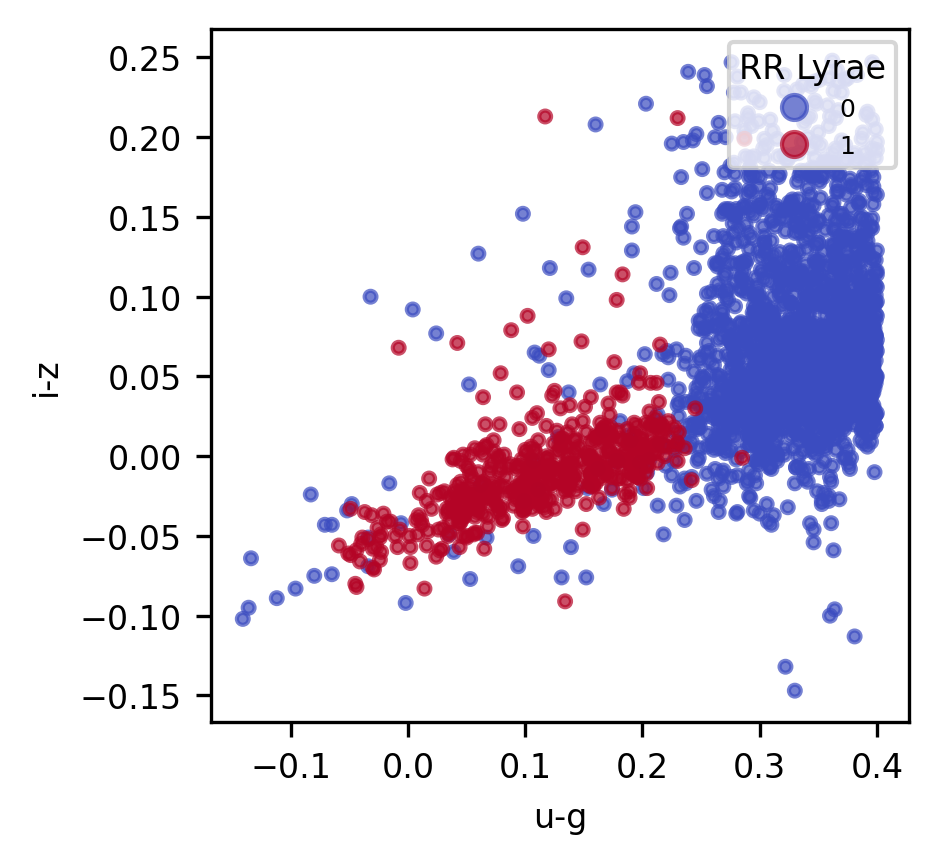

In [7]:
#complete la celda
plt.figure(figsize=(3,3))
sc=plt.scatter(df['u-g'], df['i-z'], c=df['RR_Lyrae'], cmap='coolwarm', s=8, alpha=0.7)
plt.xlabel('u-g')
plt.ylabel('i-z')
plt.legend(*sc.legend_elements(), title="RR Lyrae", loc='upper right', fontsize=6)
plt.show()

### Pregunta
1. ¿Se observan regiones donde las clases parecen separarse?

Las clases no están perfectamente separadas, pero sí existen regiones donde una clase es más predominante que la otra.

2. A simple vista, ¿esperarías que un árbol de decisión funcione razonablemente bien?

Un árbol de desicion puede funcionar perfectamente debido a su funcionamiento. Sin embargo, debido al solapamiento entre clases, la clasificación no será perfecta, además hay que tener encuenta que las clases estan desbalanceadas. 

#### Separe los datos en entrenamiento y prueba

In [8]:
X = df[["u-g", "g-r", "r-i", "i-z"]]
y = df["RR_Lyrae"]

In [9]:
#complete la celda
X_train, X_test, y_train, y_test =train_test_split(X,y,test_size=0.3, random_state=42)

In [10]:
X_train.shape

(1738, 4)

### Antes de continuar

Las clases en este problema no están perfectamente balanceadas.

Piense en la forma en que podríamos separar los datos en entrenamiento y prueba, y responda:

1. ¿Qué problema podría ocurrir si hacemos la partición de manera completamente aleatoria, sin preocuparnos por la proporción de clases?

Como las clases estan desbalanceadas, realizar una partición aleatoria generaría conjuntos de entrenamiento y pruena con proporciones de clase diferentes. 

2. ¿Por qué eso podría afectar la evaluación del modelo?

El conjunto de prueba podría no representar adecuadamente los datos reales. Si tiene una proporción de clase distinta, las métricas obtenidas podrían ser poco confiables.

3. ¿Qué tipo de precaución cree que sería razonable tomar al construir los conjuntos de entrenamiento y prueba en este caso?

Una precaución que puede ayudar en este tipo de problematica seria realizar particiones las cuales se busca mantener la misma proporción de cada clase tanto en entrenamiento como en prueba.

#### Ahora entrenaremos un árbol de decisión (modelo base)

In [11]:
model_tree = DecisionTreeClassifier(random_state=42)
model_tree.fit(X_train, y_train)
#entrene el modelo y genere las predicciones
y_pred=model_tree.predict(X_test)


In [12]:
df.RR_Lyrae.value_counts()

RR_Lyrae
0    2000
1     483
Name: count, dtype: int64

#### Visualicemos el árbol

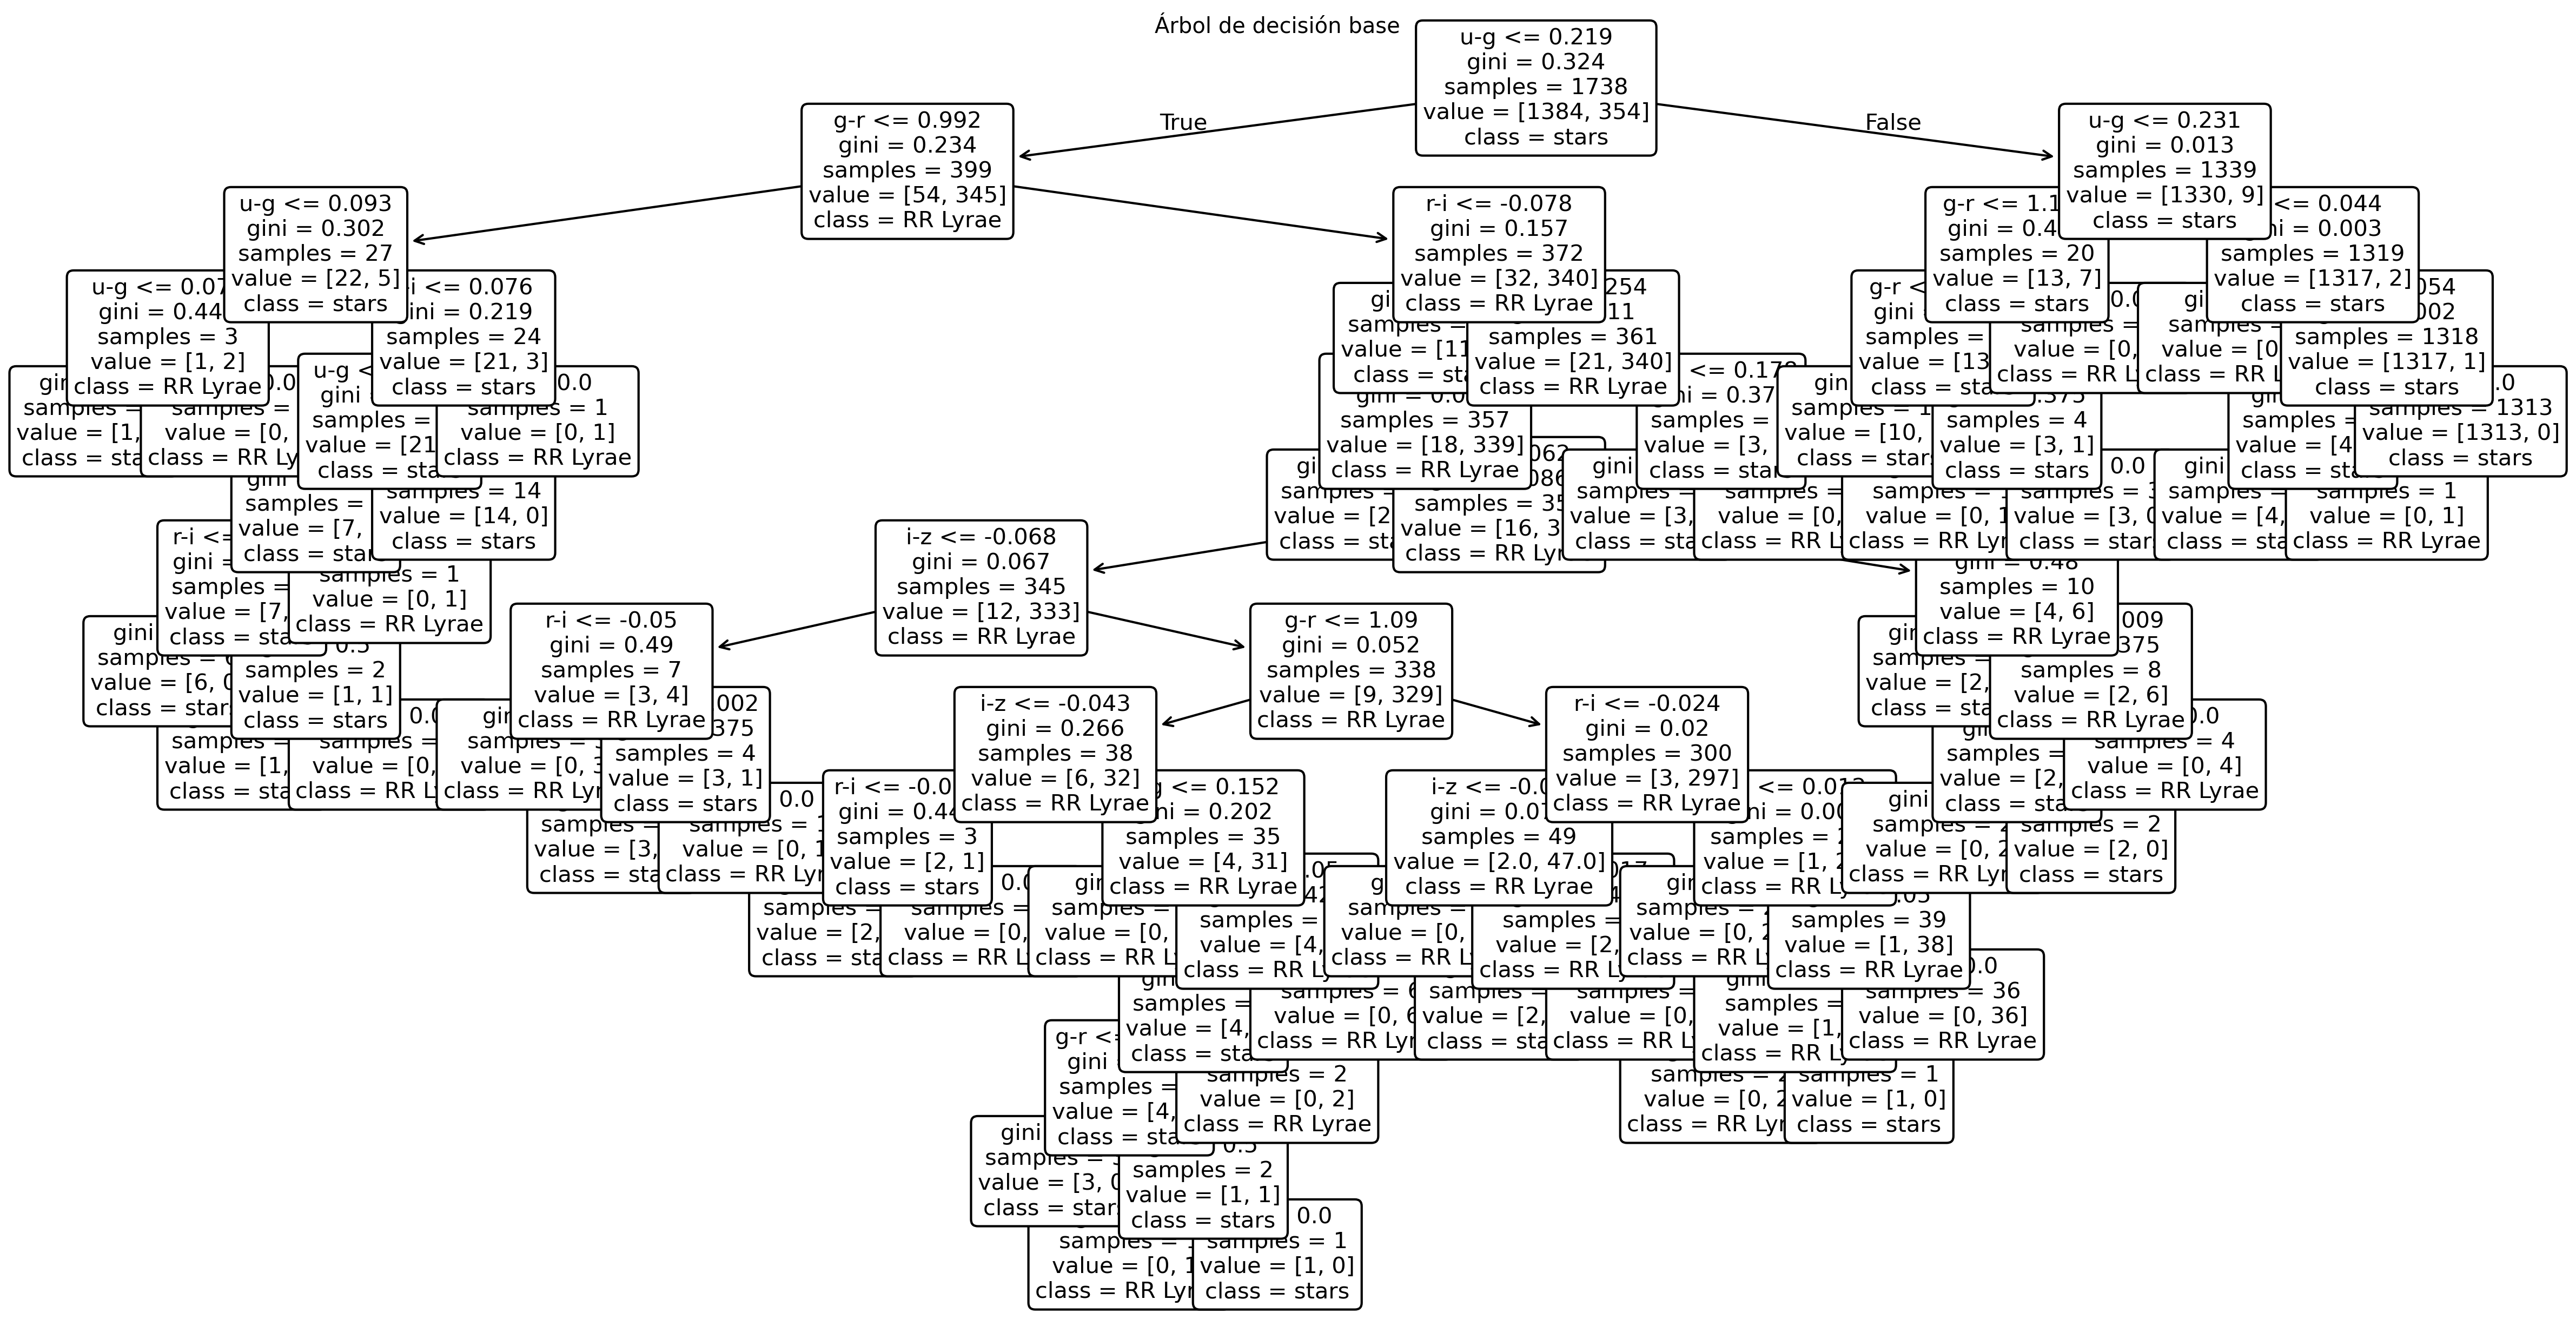

In [13]:
plt.figure(figsize=(20,10))

plot_tree(
    model_tree,
    feature_names=X.columns,
    class_names=["stars", "RR Lyrae"],
    filled=False,
    rounded=True,
    #max_depth=3,
    fontsize=10
)

plt.title("Árbol de decisión base")
plt.show()

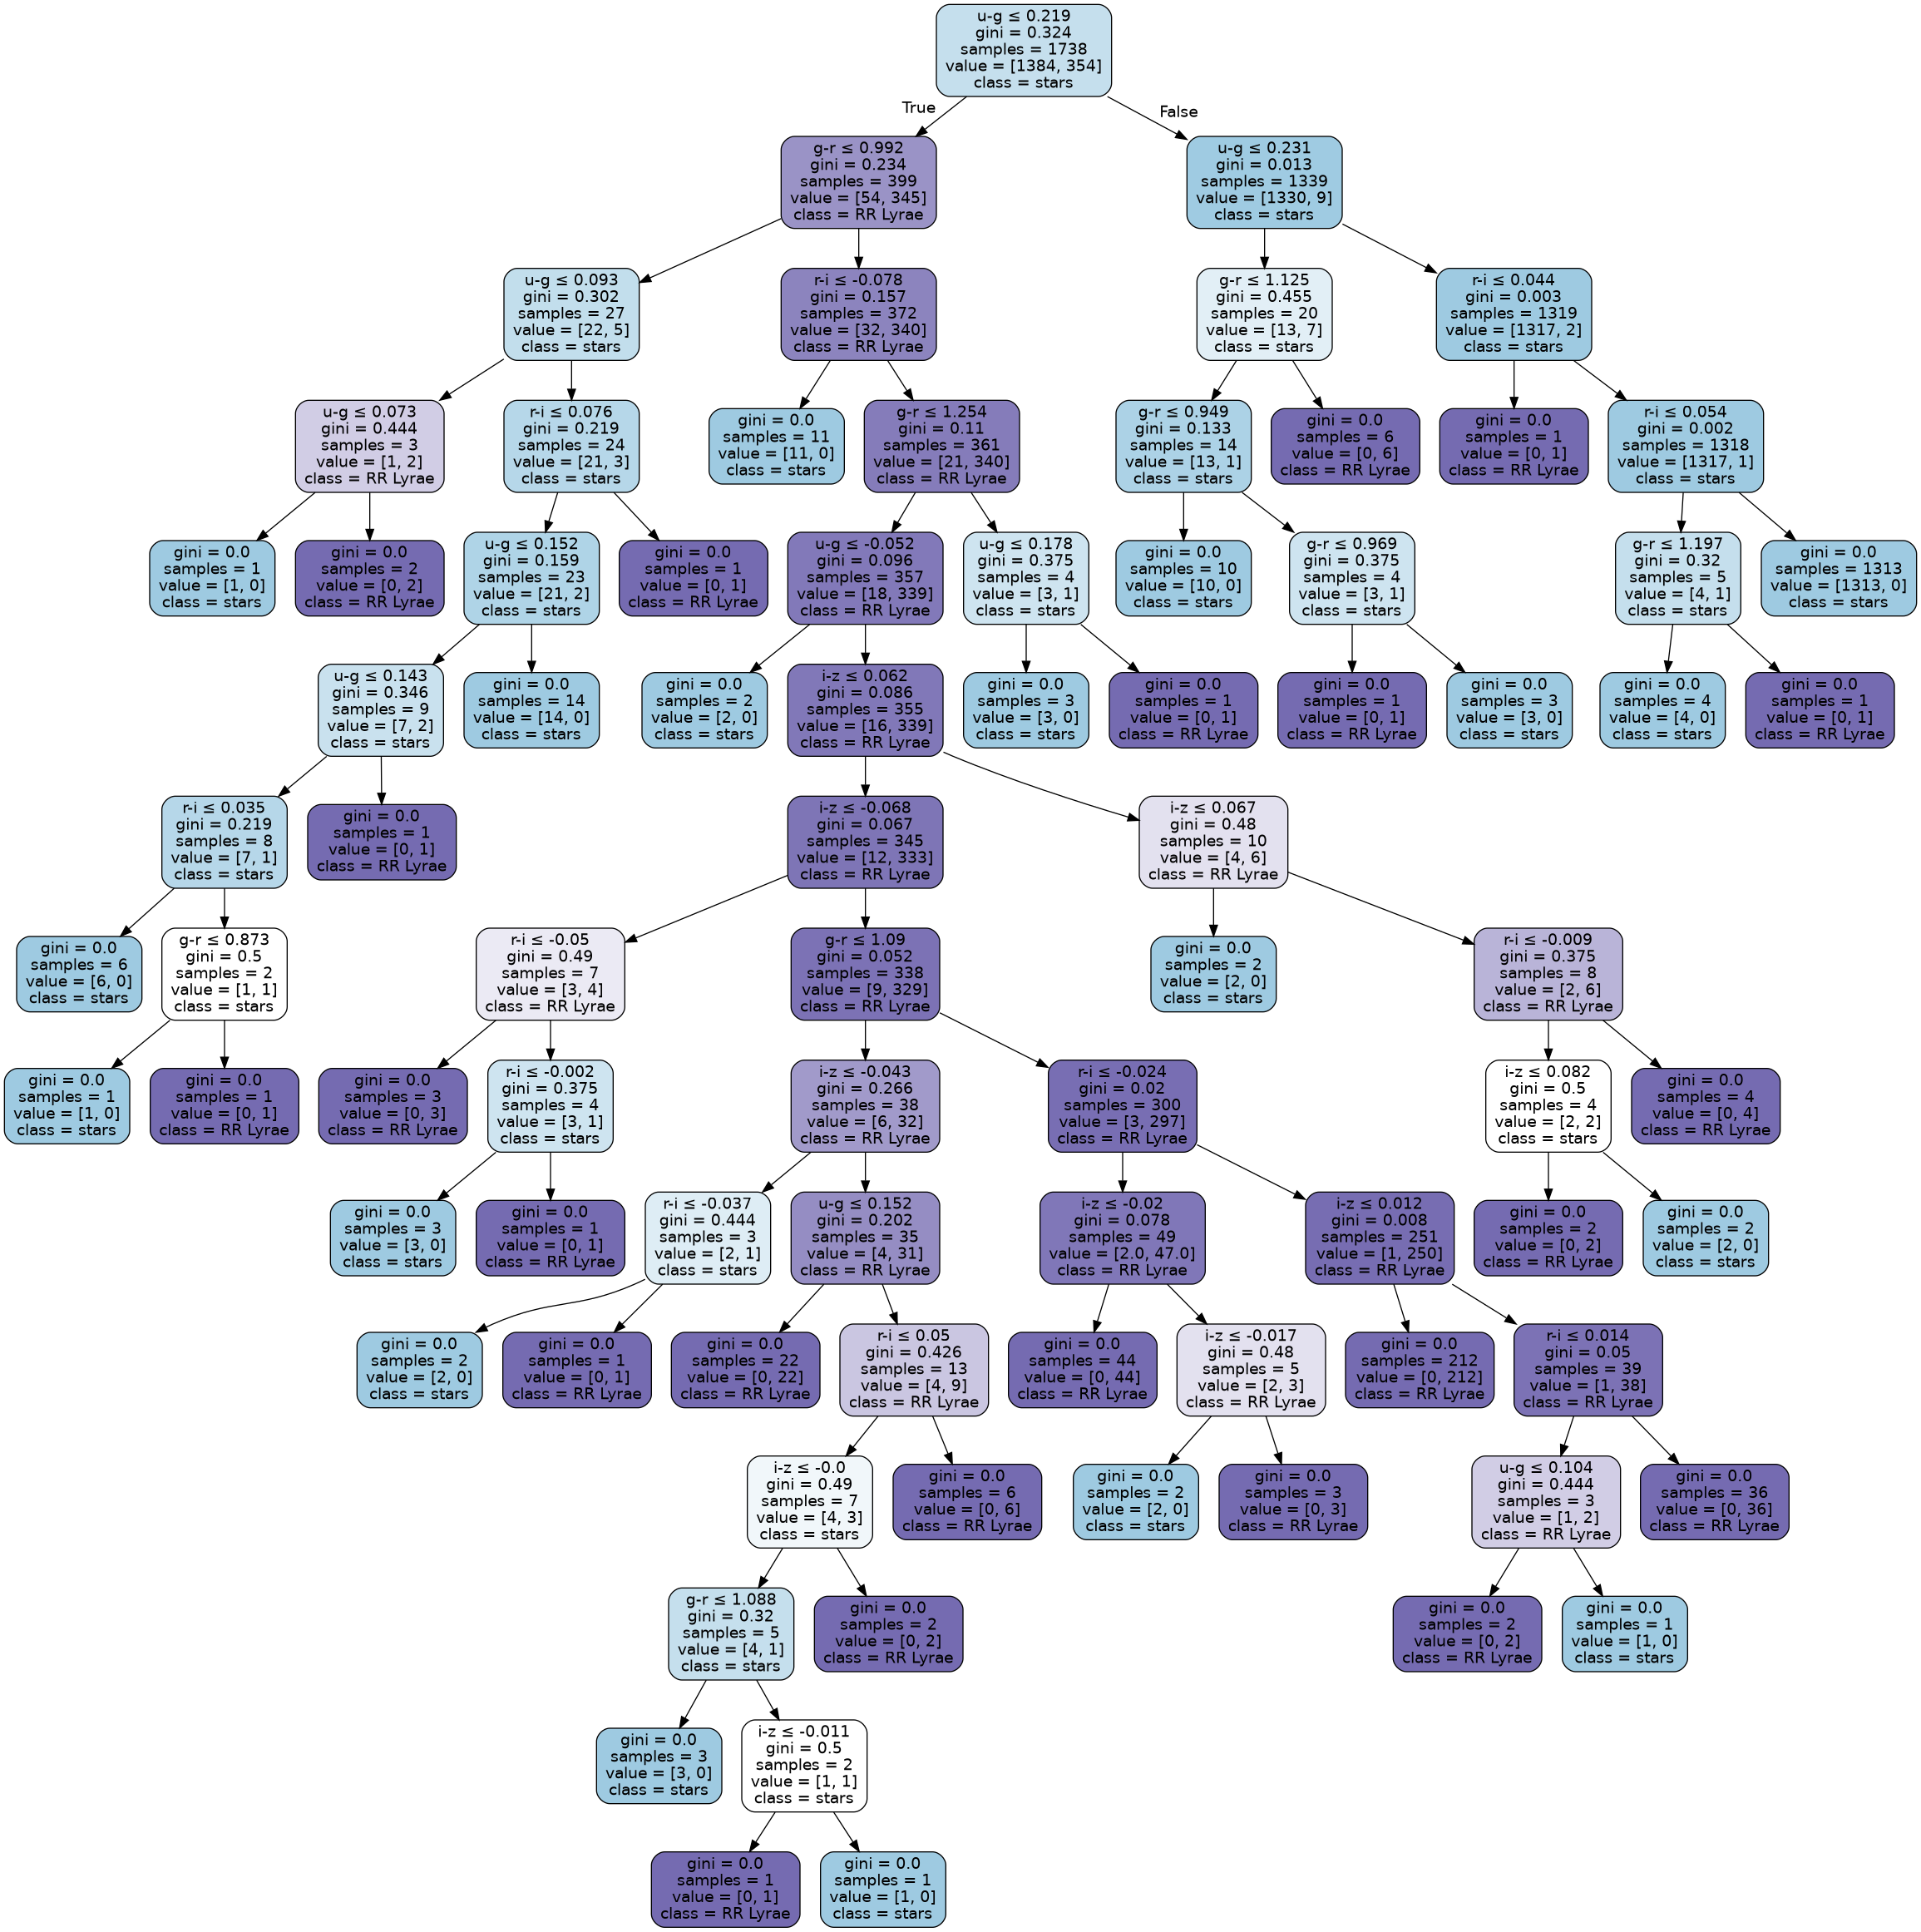

In [14]:
# Recordatorio: Las características siempre se permutan aleatoriamente en cada división.
# Por lo tanto, la mejor división encontrada puede variar, incluso con los mismos datos
# de entrenamiento y max_features=n_features, si la mejora del criterio es idéntica
# para varias divisiones enumeradas durante la búsqueda de la mejor división.
# Para obtener un comportamiento determinista durante el ajuste, random_state debe estar fijo.

dot_data = StringIO()

export_graphviz(
    model_tree,
    out_file=dot_data,
    feature_names=['u-g', 'g-r', 'r-i', 'i-z'],
    class_names=['stars', 'RR Lyrae'],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = pydotplus.graph_from_dot_data(dot_data.getvalue().replace("\n", ""))
nodes = graph.get_node_list()

for node in nodes:
    if node.get_label() and 'value = [' in node.get_label():

        values = [float(ii) for ii in node.get_label().split('value = [')[1].split(']')[0].split(',')]
        values = [int(255 * v / sum(values)) for v in values]

        if values[0] > values[1]:
            alpha = int(values[0] - values[1])
            alpha = '{:02x}'.format(alpha)
            color = '#9ecae1' + str(alpha)   # turquesa
        else:
            alpha = int(values[1] - values[0])
            alpha = '{:02x}'.format(alpha)
            color = '#756bb1' + str(alpha)   # magenta

        node.set_fillcolor(color)

Image(graph.create_png())

### Preguntas

Observe la estructura del árbol y responda brevemente:

1. ¿El árbol parece muy simple o bastante complejo? Justifique a partir del número de niveles o divisiones.

El árbol se ve bastante completo, vemos que realizaron más de 10 splits dando forma a muchas hojas de este árbol. 

2. ¿Qué desventaja podría tener un árbol demasiado grande en un problema como este?

La desventaja más grande que revela este árbol es el overfitting que está realizando una pérdida de generalización, el modelo memoriza particularidades del conjunto de entremaniento en lugar de aprender de manera adecuada.

#### Miremos las métricas accuracy para set de entrenamiento y prueba

In [15]:
print(metrics.accuracy_score(y_train, model_tree.predict(X_train))) #train score

print(metrics.accuracy_score(y_test, model_tree.predict(X_test))) #test score

1.0
0.9651006711409396


#### Otras métricas

In [16]:
print("Precision:", metrics.precision_score(y_test, y_pred))
print("Recall   :", metrics.recall_score(y_test, y_pred))
print("F1-score :", metrics.f1_score(y_test, y_pred))

Precision: 0.8759124087591241
Recall   : 0.9302325581395349
F1-score : 0.9022556390977443


In [17]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[599,  17],
       [  9, 120]])

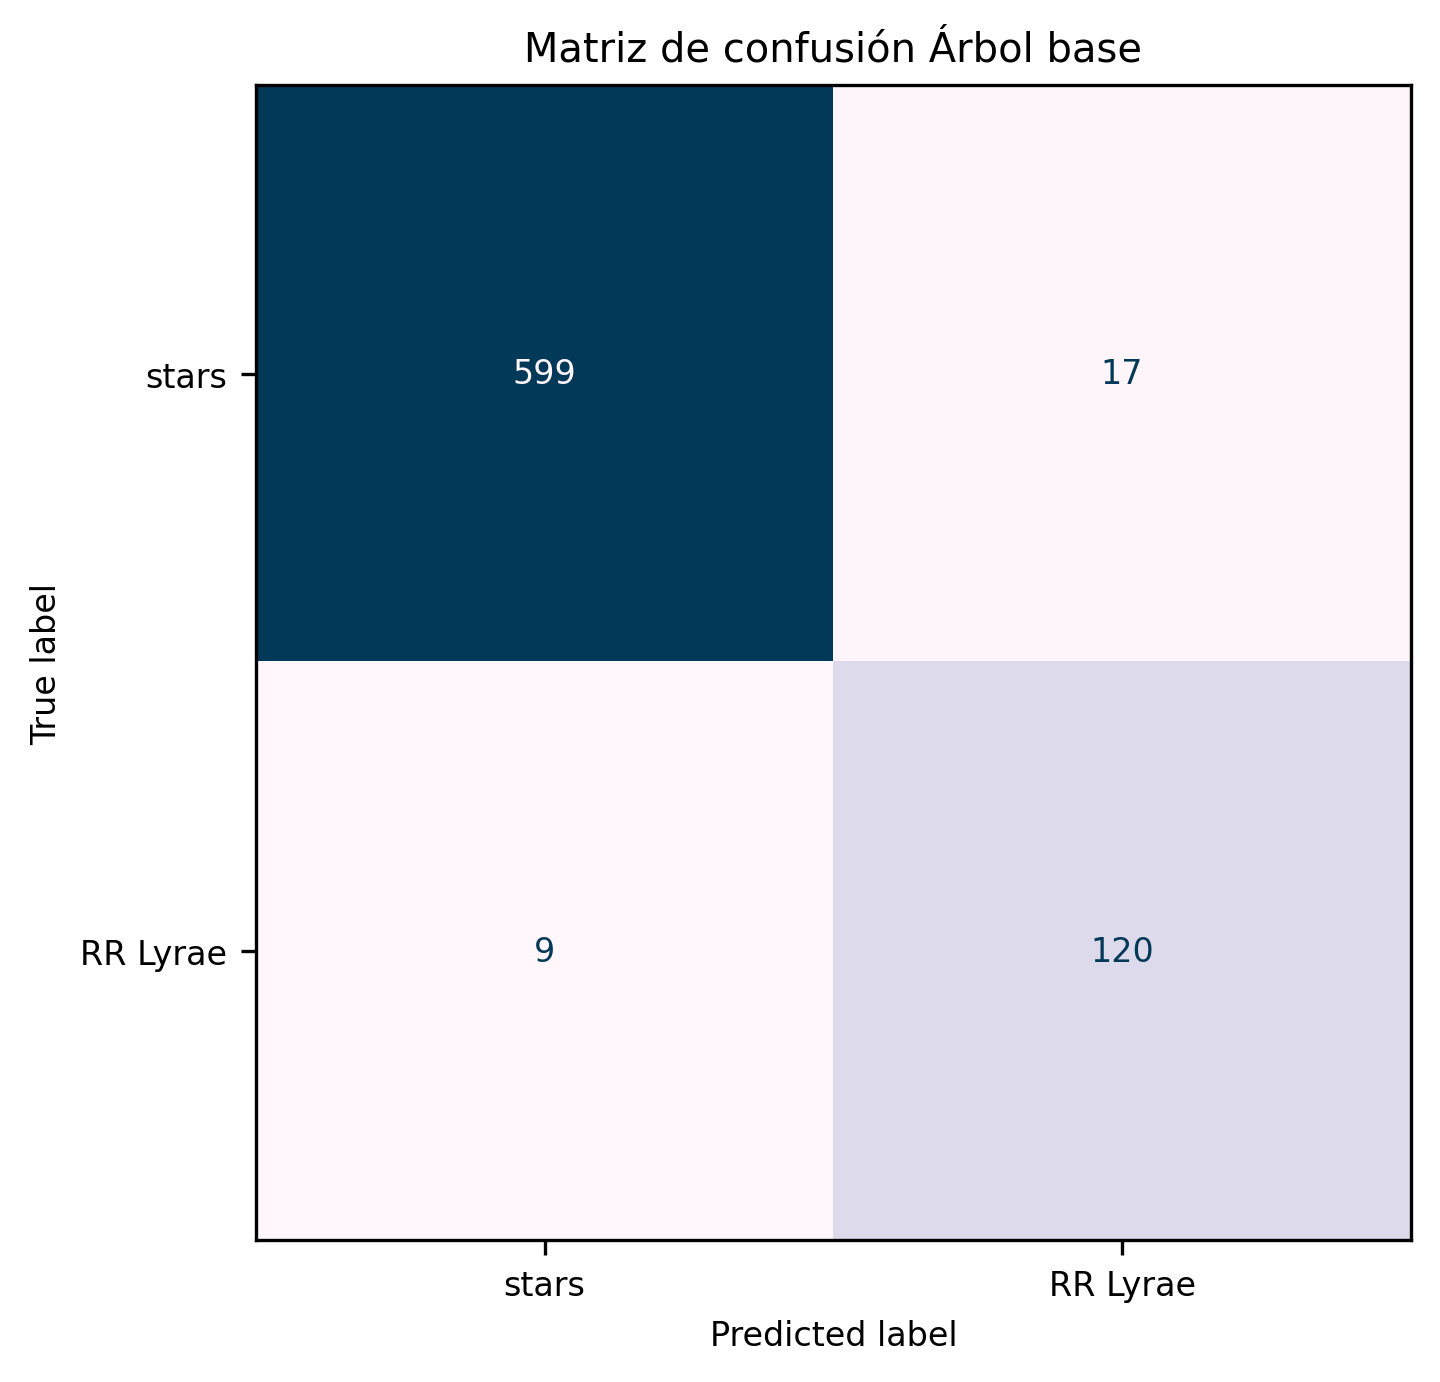

In [18]:
fig, ax = plt.subplots(figsize=(5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["stars", "RR Lyrae"])
disp.plot(cmap="PuBu", ax=ax, colorbar=False)

plt.title("Matriz de confusión Árbol base")
plt.show()

#### A partir de la matriz de confusión obtenida:
1.  Identifique los valores de:
   - verdaderos positivos (TP): 120
   - verdaderos negativos (TN): 599
   - falsos positivos (FP): 17
   - falsos negativos (FN): 9
2. Calcule las métricas "a mano"

Total = 745

Accuracy = (TP+TN)/Total = 0.9651

Precision = TP/(TP+FP) = 0.8759

Recall = TP/(TP+FN) =  0.9302

F1score = 2 (Presicion * Recall)/(Presicion + Recal)= 0.9023

### Preguntas
1. Explique con sus palabras qué significa, en este problema:
   - un falso positivo: Ocurre cuando el modelo clasifica a una estrella como si fuera una RR Lyrae (Contaminacion)
   - un falso negativo: Ocurre cuando una estrella que es RR Lyrae es clasificada como estrella común.

2. Si el objetivo científico fuera encontrar la mayor cantidad posible de RR Lyrae, ¿qué tipo de error preocuparía más?

El error que más preocuparía serían los falsos negativos. Como buscamos maximizar la completitud debemos de trabajar con la metrica de recall,  

3. Si el objetivo fuera construir una muestra final más limpia, ¿qué tipo de error preocuparía más?

El error que más preocuparía serían los falsos positivos, necesitamos obtener una muestra de alta pureza, por lo que trabajar con la precision sería idóneo. 

#### Todo parece funcionar bien, pero sólo hicimos un split. Necesitamos que el resultados sea robusto. Para esto, implementaremos Cross-validation usando [k-fold](https://scikit--learn-org.translate.goog/stable/modules/generated/sklearn.model_selection.KFold.html?_x_tr_sl=en&_x_tr_tl=es&_x_tr_hl=es&_x_tr_pto=tc)

In [19]:
# Esta es la versión estándar. Importante: no baraja los datos, por lo que si tus
# ejemplos positivos están todos al principio o al final, podría llevar a resultados
# desastrosos.

cv1 = KFold(n_splits = 5)

#Esta es la versión 2: se ha añadido el barajado (¡recomendado!)

cv2 = KFold(shuffle = True, n_splits = 5, random_state=5)

# LA ESTRATIFICACIÓN asegura que las distribuciones de clases en cada división se
# asemejen a las del conjunto de datos completo.

cv3 = StratifiedKFold(shuffle = True, n_splits = 5, random_state=5)


### Efecto de la estratificación: veamos el conteo de clases en cada conjunto de divisiones.

In [20]:
cv1.split(X, y)

<generator object _BaseKFold.split at 0x757c443e2ce0>

In [21]:
for train, test in cv1.split(X, y):
...     print('train -  {}   |   test -  {}'.format(
...         np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1503  483]   |   test -  [497]
train -  [1503  483]   |   test -  [497]
train -  [1503  483]   |   test -  [497]
train -  [1504  483]   |   test -  [496]
train -  [1987]   |   test -  [ 13 483]


In [22]:
for train, test in cv2.split(X, y):
...     print('train -  {}   |   test -  {}'.format(
...         np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1600  386]   |   test -  [400  97]
train -  [1610  376]   |   test -  [390 107]
train -  [1587  399]   |   test -  [413  84]
train -  [1599  388]   |   test -  [401  95]
train -  [1604  383]   |   test -  [396 100]


In [23]:
for train, test in cv3.split(X, y):
...     print('train -  {}   |   test -  {}'.format(
...         np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1600  386]   |   test -  [400  97]
train -  [1600  386]   |   test -  [400  97]
train -  [1600  386]   |   test -  [400  97]
train -  [1600  387]   |   test -  [400  96]
train -  [1600  387]   |   test -  [400  96]


### La función [`cross_validate`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html#sklearn.model_selection.cross_validate) proporciona los puntajes (especificados por el parámetro de evaluación elegido), en forma de diccionario.

In [24]:
scores1 = cross_validate(DecisionTreeClassifier(), X, y, cv = cv1, scoring = 'accuracy')

scores2 = cross_validate(DecisionTreeClassifier(), X, y, cv = cv2, scoring = 'accuracy')

scores3 = cross_validate(DecisionTreeClassifier(), X, y, cv = cv3, scoring = 'accuracy')

In [25]:
scores3

{'fit_time': array([0.0031054 , 0.00269318, 0.00309777, 0.00340557, 0.00286555]),
 'score_time': array([0.00086308, 0.00091457, 0.00111485, 0.00088501, 0.00084805]),
 'test_score': array([0.98390342, 0.96981891, 0.96579477, 0.97782258, 0.96169355])}

Solo nos interesa el 'test_score'

#### Calculamos el promedio y $\sigma$

In [26]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['test_score'].std()))

0.785 0.380


In [27]:
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['test_score'].std()))

0.966 0.011


In [28]:
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['test_score'].std()))

0.972 0.008


La validación cruzada sin barajar (`cv1`) produce un resultado muy inestable, con una desviación estándar extremadamente alta. Esto ocurre porque los datos están ordenados por clase, de modo que algunos folds no representan bien el problema completo.

Al activar el barajado (`cv2`), el rendimiento mejora drásticamente y la dispersión disminuye. Sin embargo, el método que resulta más apropiado para este problema es `StratifiedKFold` (`cv3`), ya que además de mezclar los datos, conserva aproximadamente la proporción de clases en cada fold.

En problemas de clasificación desbalanceada, esta última estrategia suele ser la más recomendable.

In [29]:
scores1 = cross_validate(DecisionTreeClassifier(random_state=1), X,y, cv = cv1, scoring = 'recall')

scores2 = cross_validate(DecisionTreeClassifier(random_state=1), X,y, cv = cv2, scoring = 'recall')

scores3 = cross_validate(DecisionTreeClassifier(random_state=1), X,y, cv = cv3, scoring = 'recall')

/home/ivanf/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ivanf/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ivanf/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ivanf/anaconda3/lib/python3.13/site-packages/sklearn/metri

In [30]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['test_score'].std()))
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['test_score'].std()))
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['test_score'].std()))

nan nan
0.903 0.016
0.925 0.019


### ¿Por qué aparece este warning?

En algunos folds generados por `KFold` sin barajado, el conjunto de prueba contiene solo ejemplos de una clase. En ese caso, el recall de la clase positiva (RR Lyrae) no puede calcularse, porque no hay positivos reales en ese fold.

Esto muestra que una estrategia de partición inadecuada puede hacer que la evaluación sea inestable, engañosa o incluso inválida.

#### También extraeremos los train scores, que nos servirán cuando estemos diagnosticando el modelo a través de bias vs variance.¶

In [31]:
scores1 = cross_validate(DecisionTreeClassifier(), X,y, cv = cv1, scoring = 'recall', \
                         return_train_score = True)

scores2 = cross_validate(DecisionTreeClassifier(), X,y, cv = cv2, scoring = 'recall', \
                         return_train_score = True)

scores3 = cross_validate(DecisionTreeClassifier(), X,y, cv = cv3, scoring = 'recall',
                         return_train_score = True)

/home/ivanf/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ivanf/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ivanf/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ivanf/anaconda3/lib/python3.13/site-packages/sklearn/metri

In [32]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['train_score'].mean()))
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['train_score'].mean()))
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['train_score'].mean()))

nan nan
0.905 1.000
0.930 1.000


### La función  `cross_validate` es útil para calcular el puntaje, pero no produce etiquetas predichas.

#### Estas pueden obtenerse utilizando la función [`cross_val_predict`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_predict.html), que guarda las predicciones para cada uno de los k-folds de prueba y las compila juntas.


In [33]:
model1 = DecisionTreeClassifier(random_state = 3)

y_cv3 = cross_val_predict(model1, X,y, cv = cv3)
# Estas son las predicciones,
# y son independientes del parámetro de evaluación

In [34]:
metrics.confusion_matrix(targets,y_cv3)

array([[1955,   45],
       [  33,  450]])

### Sin embargo, las cosas pueden cambiar si uso un esquema de validación cruzada diferente:

In [35]:
model2 = DecisionTreeClassifier(random_state = 3)

y_cv2 = cross_val_predict(model2, X,y, cv = cv2)

In [36]:
np.sum(y_cv3-y_cv2)

np.int64(10)

In [37]:
np.sum(y_cv2)

np.int64(485)

In [38]:
np.sum(y_cv3 != y_cv2) #comparando las predicciones

np.int64(52)

In [39]:
metrics.confusion_matrix(targets,y_cv2)

array([[1955,   45],
       [  43,  440]])

In [40]:
metrics.confusion_matrix(targets,y_cv3)

array([[1955,   45],
       [  33,  450]])

In [41]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=5,
                        n_jobs=-1, train_sizes=np.linspace(0.2, 1.0, 5), scoring = 'accuracy'):
    """
    Generate a simple plot of the test and training learning curve.

    Parameters
    ----------
    estimator : object type that implements the "fit" and "predict" methods
        An object of that type which is cloned for each validation.

    title : string
        Title for the chart.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features), optional
        Target relative to X for classification or regression;
        None for unsupervised learning.

    ylim : tuple, shape (ymin, ymax), optional
        Defines minimum and maximum yvalues plotted.

    cv : int, cross-validation generator or an iterable, optional
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:
          - None, to use the default 3-fold cross-validation,
          - integer, to specify the number of folds.
          - :term:`CV splitter`,
          - An iterable yielding (train, test) splits as arrays of indices.

        For integer/None inputs, if ``y`` is binary or multiclass,
        :class:`StratifiedKFold` used. If the estimator is not a classifier
        or if ``y`` is neither binary nor multiclass, :class:`KFold` is used.

        Refer :ref:`User Guide <cross_validation>` for the various
        cross-validators that can be used here.

    n_jobs : int or None, optional (default=None)
        Number of jobs to run in parallel.
        ``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.
        ``-1`` means using all processors. See :term:`Glossary <n_jobs>`
        for more details.

    train_sizes : array-like, shape (n_ticks,), dtype float or int
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve. If the dtype is float, it is regarded as a
        fraction of the maximum size of the training set (that is determined
        by the selected validation method), i.e. it has to be within (0, 1].
        Otherwise it is interpreted as absolute sizes of the training sets.
        Note that for classification the number of samples usually have to
        be big enough to contain at least one sample from each class.
        (default: np.linspace(0.1, 1.0, 5))
    """
    plt.figure(figsize=(10,6))
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel(str(scoring))

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring = scoring, shuffle=True, random_state=42)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Test score from cross-validation")

    plt.legend(loc="best")
    return plt

In [42]:
model = DecisionTreeClassifier(random_state = 5)

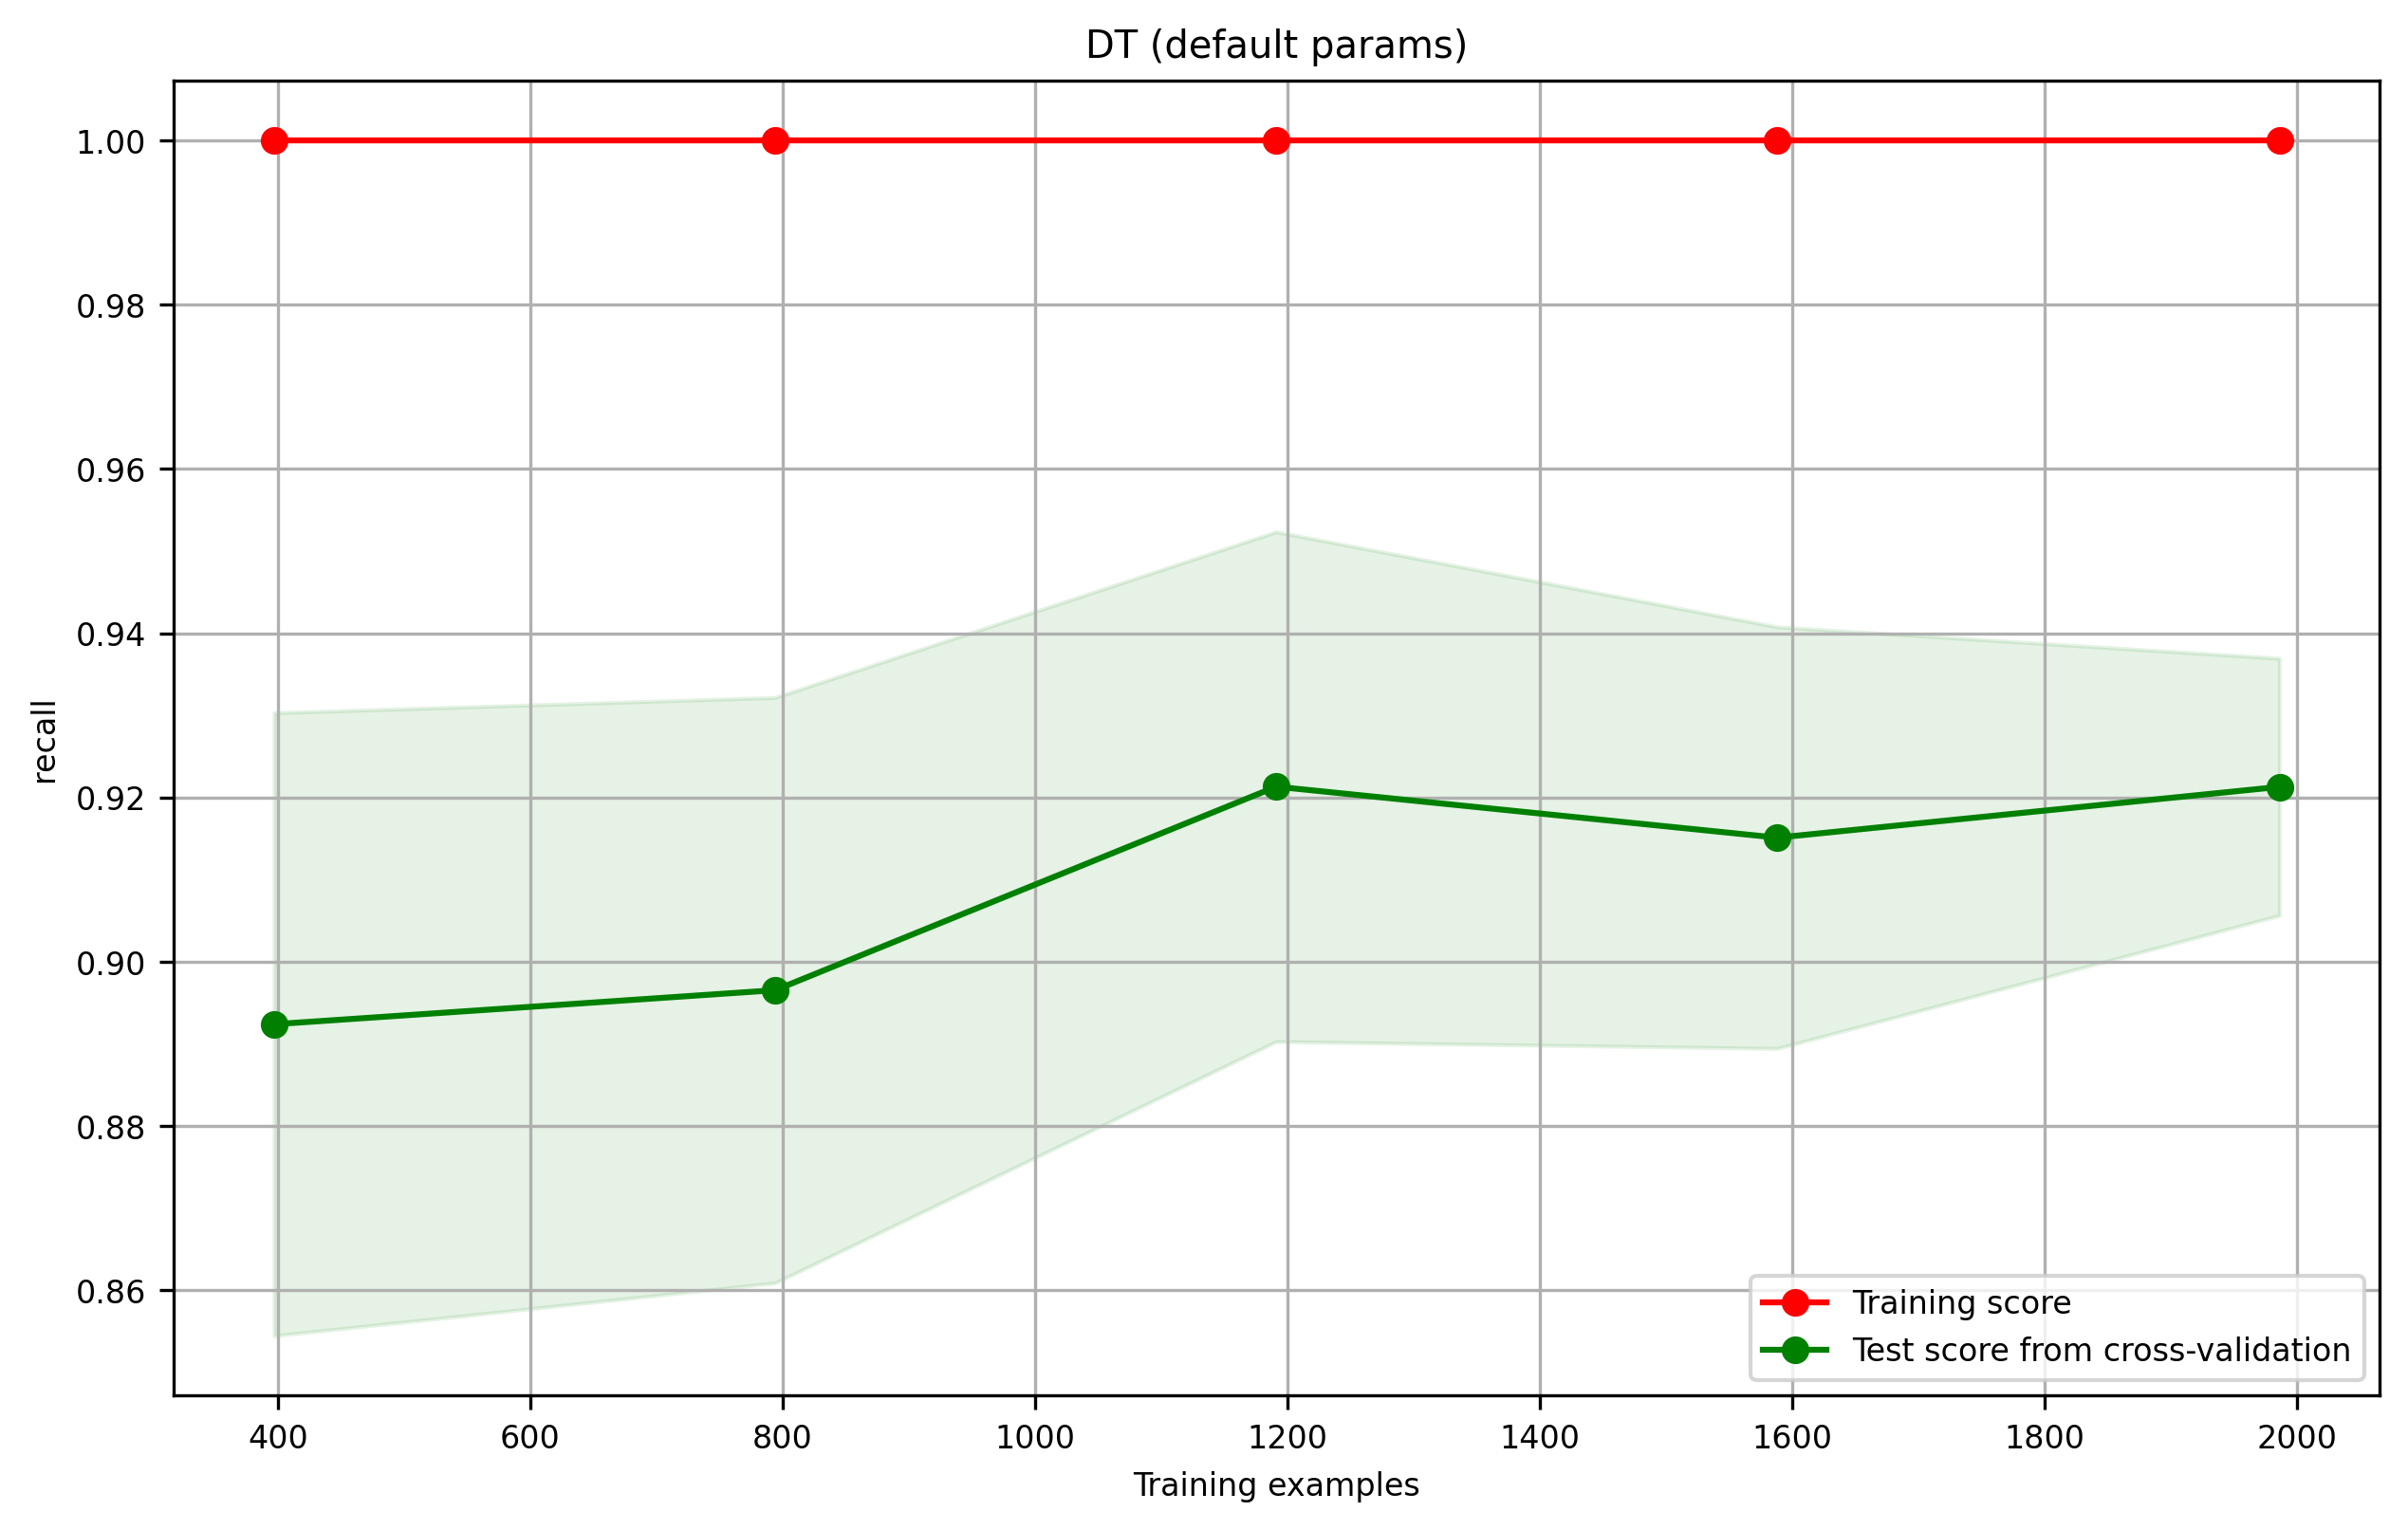

In [43]:
plot_learning_curve(model, 'DT (default params)', X, y,  cv = cv3, scoring = 'recall');

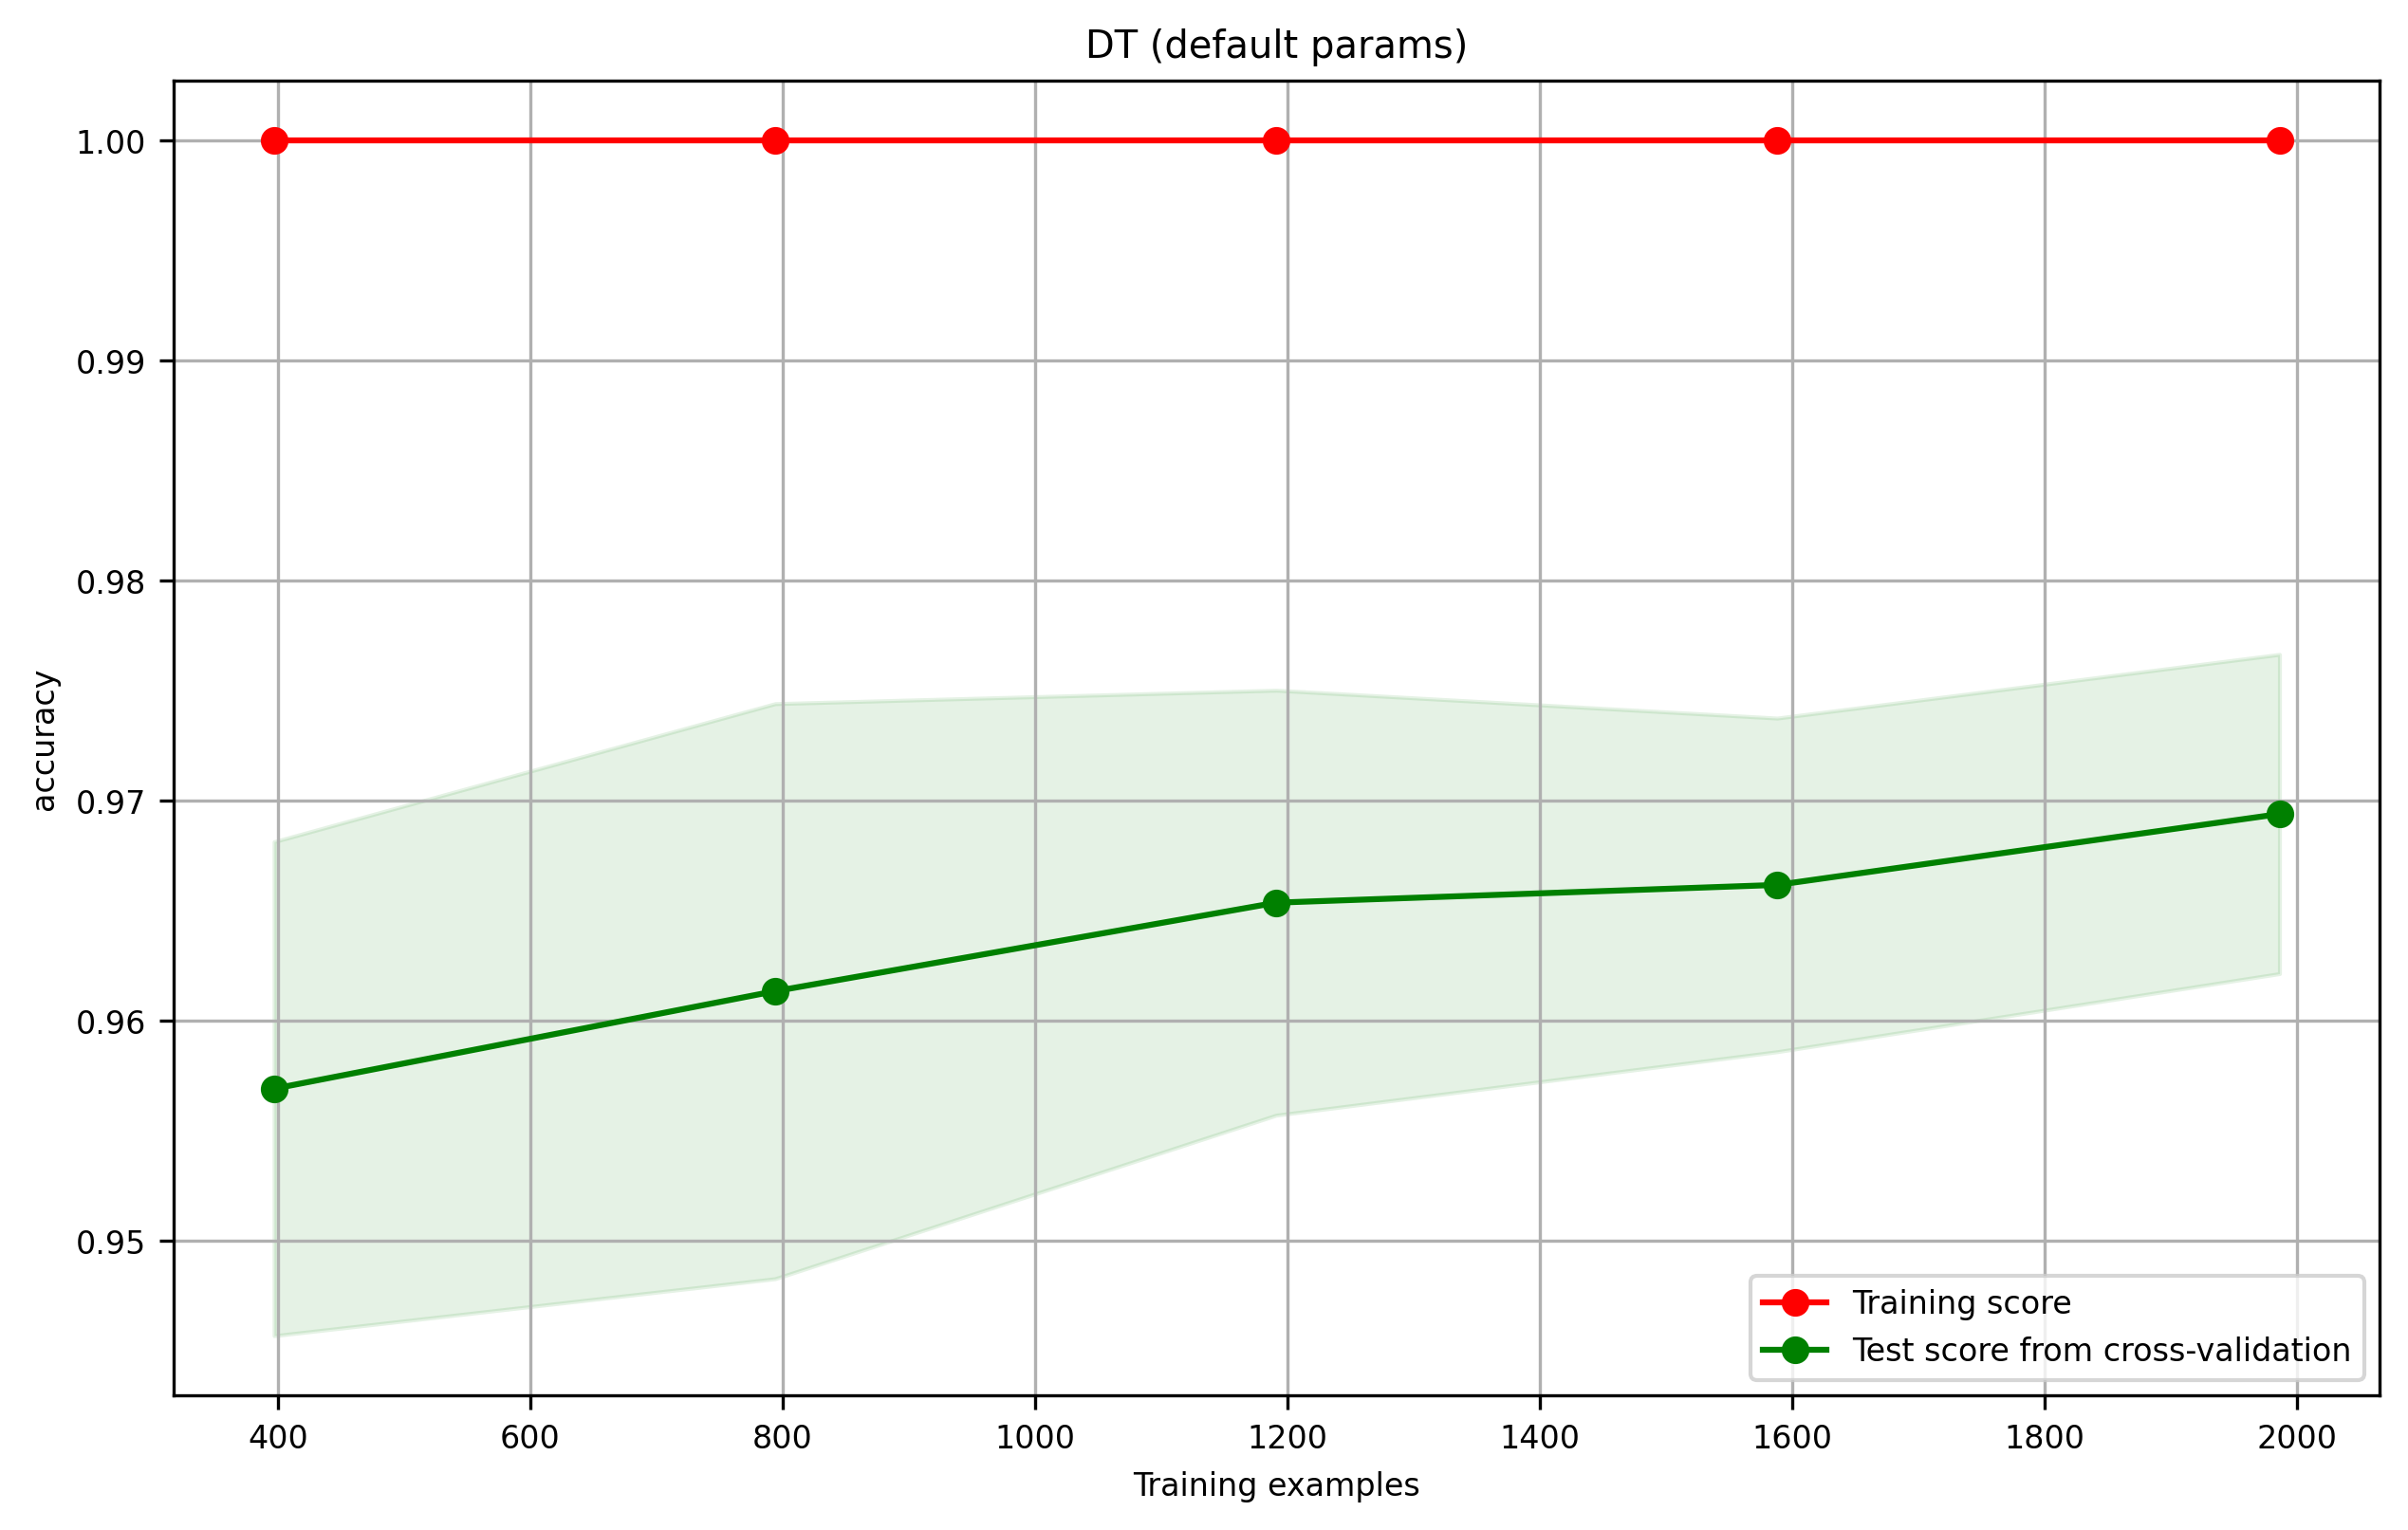

In [44]:
plot_learning_curve(model, 'DT (default params)', X, y,  cv = cv3, scoring = 'accuracy');

### **Preguntas**

Responda brevemente:

1. ¿Existe una brecha entre la curva de entrenamiento y la de validación? ¿Qué sugiere eso?

Sí, existe una brecha clara en ambas métricas. La curva de entrenamiento permanece en 1 para todos los tamaños de la muestra, mientrsa que la curva de validacion se ubica por debajo.

2. ¿El rendimiento de validación mejora al agregar más ejemplos?

Sí, hay una tendencia ascendente leve en ambos gráficos: el recall de validación sube desde los 400 hasta los 2000 ejemplos, y el accuracy también lo hace. Sin embargo la mejora es poca, y no es monótona y el sombreado verde correspondiente a ($\bar{x} \pm \sigma$) sigue siendo muy ancha. 

3. ¿Hablaría aquí de alto sesgo, alta varianza o sobreajuste moderado? Justifique.

Bajo este contexto, podemos concluir que se trata de un problema de alta varianaza con sobreajuste. No correspondería a un alto bias debido a que el score del set de entrenamiento no es bajo, si no que es perfecto, se mantiene en 1 a lo largo de todo los datos. El árbol de decisión al no tener limitaciones crece hasta memorizar cada ejemplo de entrenamiento. Este sobreajuste produciria la pérdida de generalidad.

4. Escriba una conclusión general sobre el comportamiento del árbol base a partir de estas curvas.

El árbol de decisión sobreajusta los datos de entrenamiento en métricas como recall y accuracy. La capacidad de memorización es tan alta que en el entrenamiento, para todos los tamaños de la muestra obtiene un score perfecto. Aumentar la cantidad de datos ayudaría a mejorar la generalizacion. De todas formas el árbol necesita modelarse con  hiperparámetros, ya sean de profundidad o aplicar poda, así reduciriamos su complejidad y mejoraria la generalización que pueda tener.


### Desafío: ¿un árbol más simple generaliza mejor?

Entrene ahora un segundo árbol, más restringido que el árbol base. Por ejemplo, puede probar con:

- `max_depth=3`, o
- `min_samples_leaf=10`

Luego compare su rendimiento con el árbol base usando:

- accuracy
- precision
- recall
- F1-score

In [45]:
model_tree_simple = DecisionTreeClassifier(max_depth=3, random_state=42)

scoring = ['accuracy', 'precision', 'recall', 'f1']

scores_base = cross_validate(
    DecisionTreeClassifier(random_state=42),
    X, y, cv=cv3, scoring=scoring
)

scores_simple = cross_validate(
    model_tree_simple,
    X, y, cv=cv3, scoring=scoring
)

print("Árbol sin restricciones ")
for m in scoring:
    print(f"{m:10s}: {scores_base['test_' + m].mean():.3f} ± {scores_base['test_' + m].std():.3f}")

print("Árbol Simple (max_depth=3) ")
for m in scoring:
    print(f"{m:10s}: {scores_simple['test_' + m].mean():.3f} ± {scores_simple['test_' + m].std():.3f}")

Árbol sin restricciones 
accuracy  : 0.971 ± 0.004
precision : 0.920 ± 0.012
recall    : 0.932 ± 0.014
f1        : 0.926 ± 0.011
Árbol Simple (max_depth=3) 
accuracy  : 0.977 ± 0.008
precision : 0.925 ± 0.023
recall    : 0.961 ± 0.024
f1        : 0.942 ± 0.019


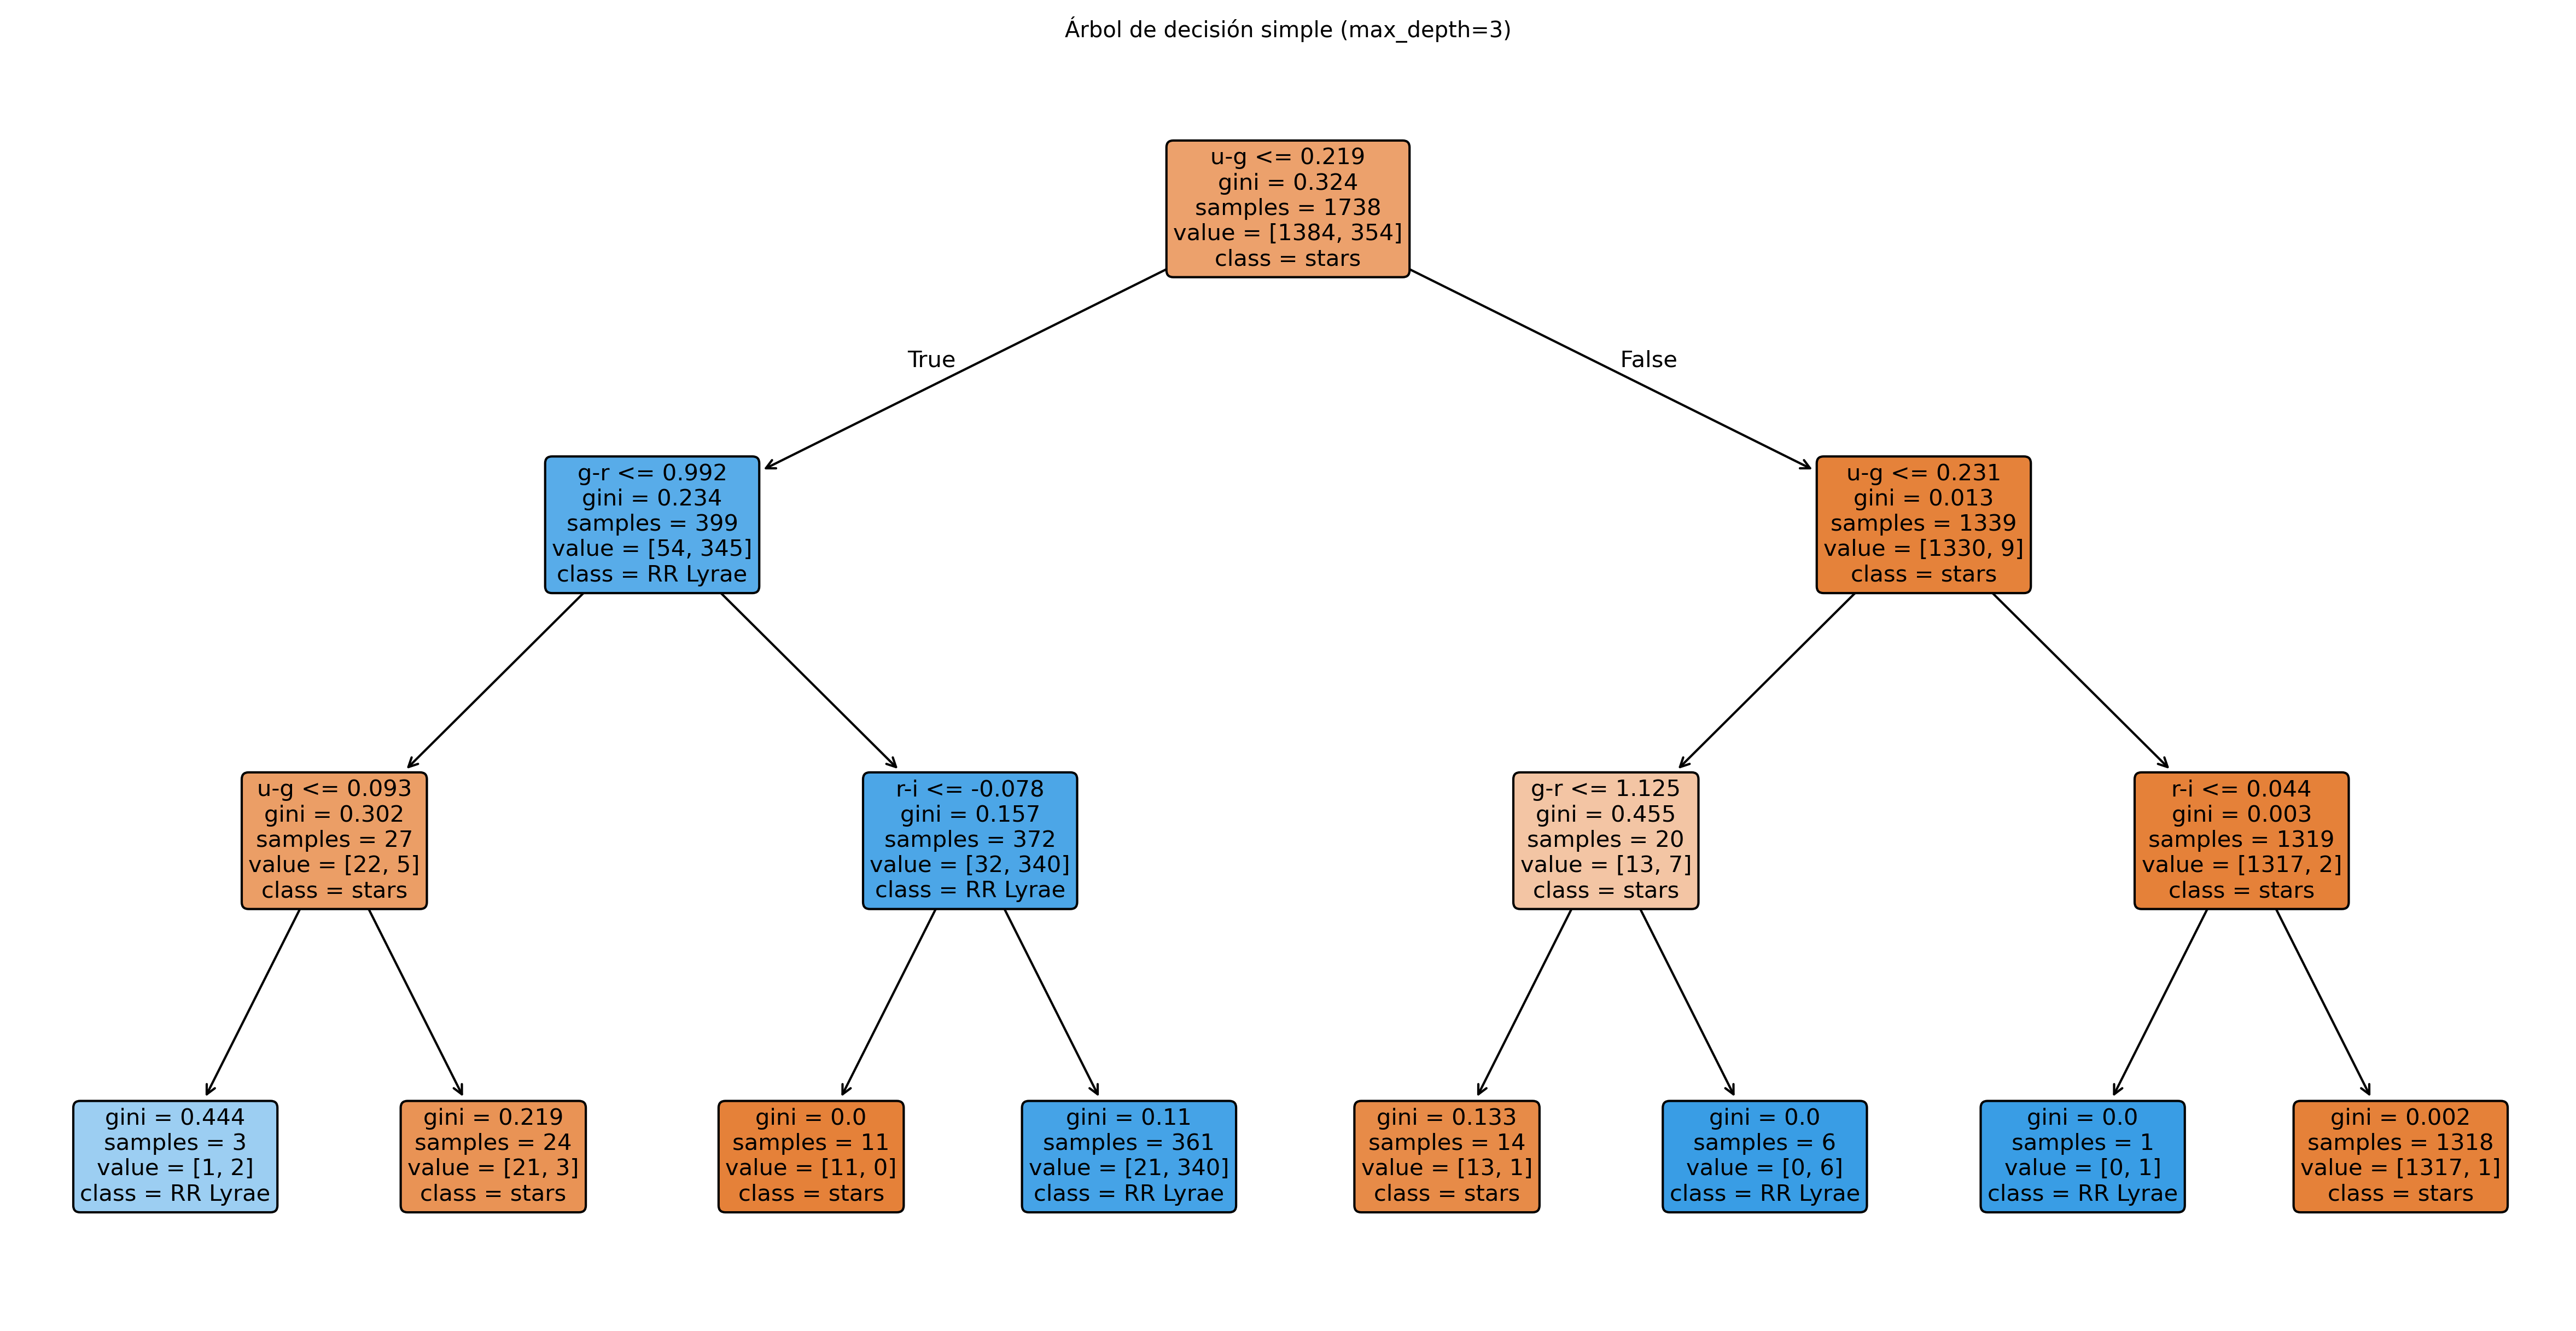

In [46]:
model_tree_simple.fit(X_train, y_train)

plt.figure(figsize=(20,10))

plot_tree(
    model_tree_simple,
    feature_names=X.columns,
    class_names=["stars", "RR Lyrae"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Árbol de decisión simple (max_depth=3)")
plt.show()

<module 'matplotlib.pyplot' from '/home/ivanf/anaconda3/lib/python3.13/site-packages/matplotlib/pyplot.py'>

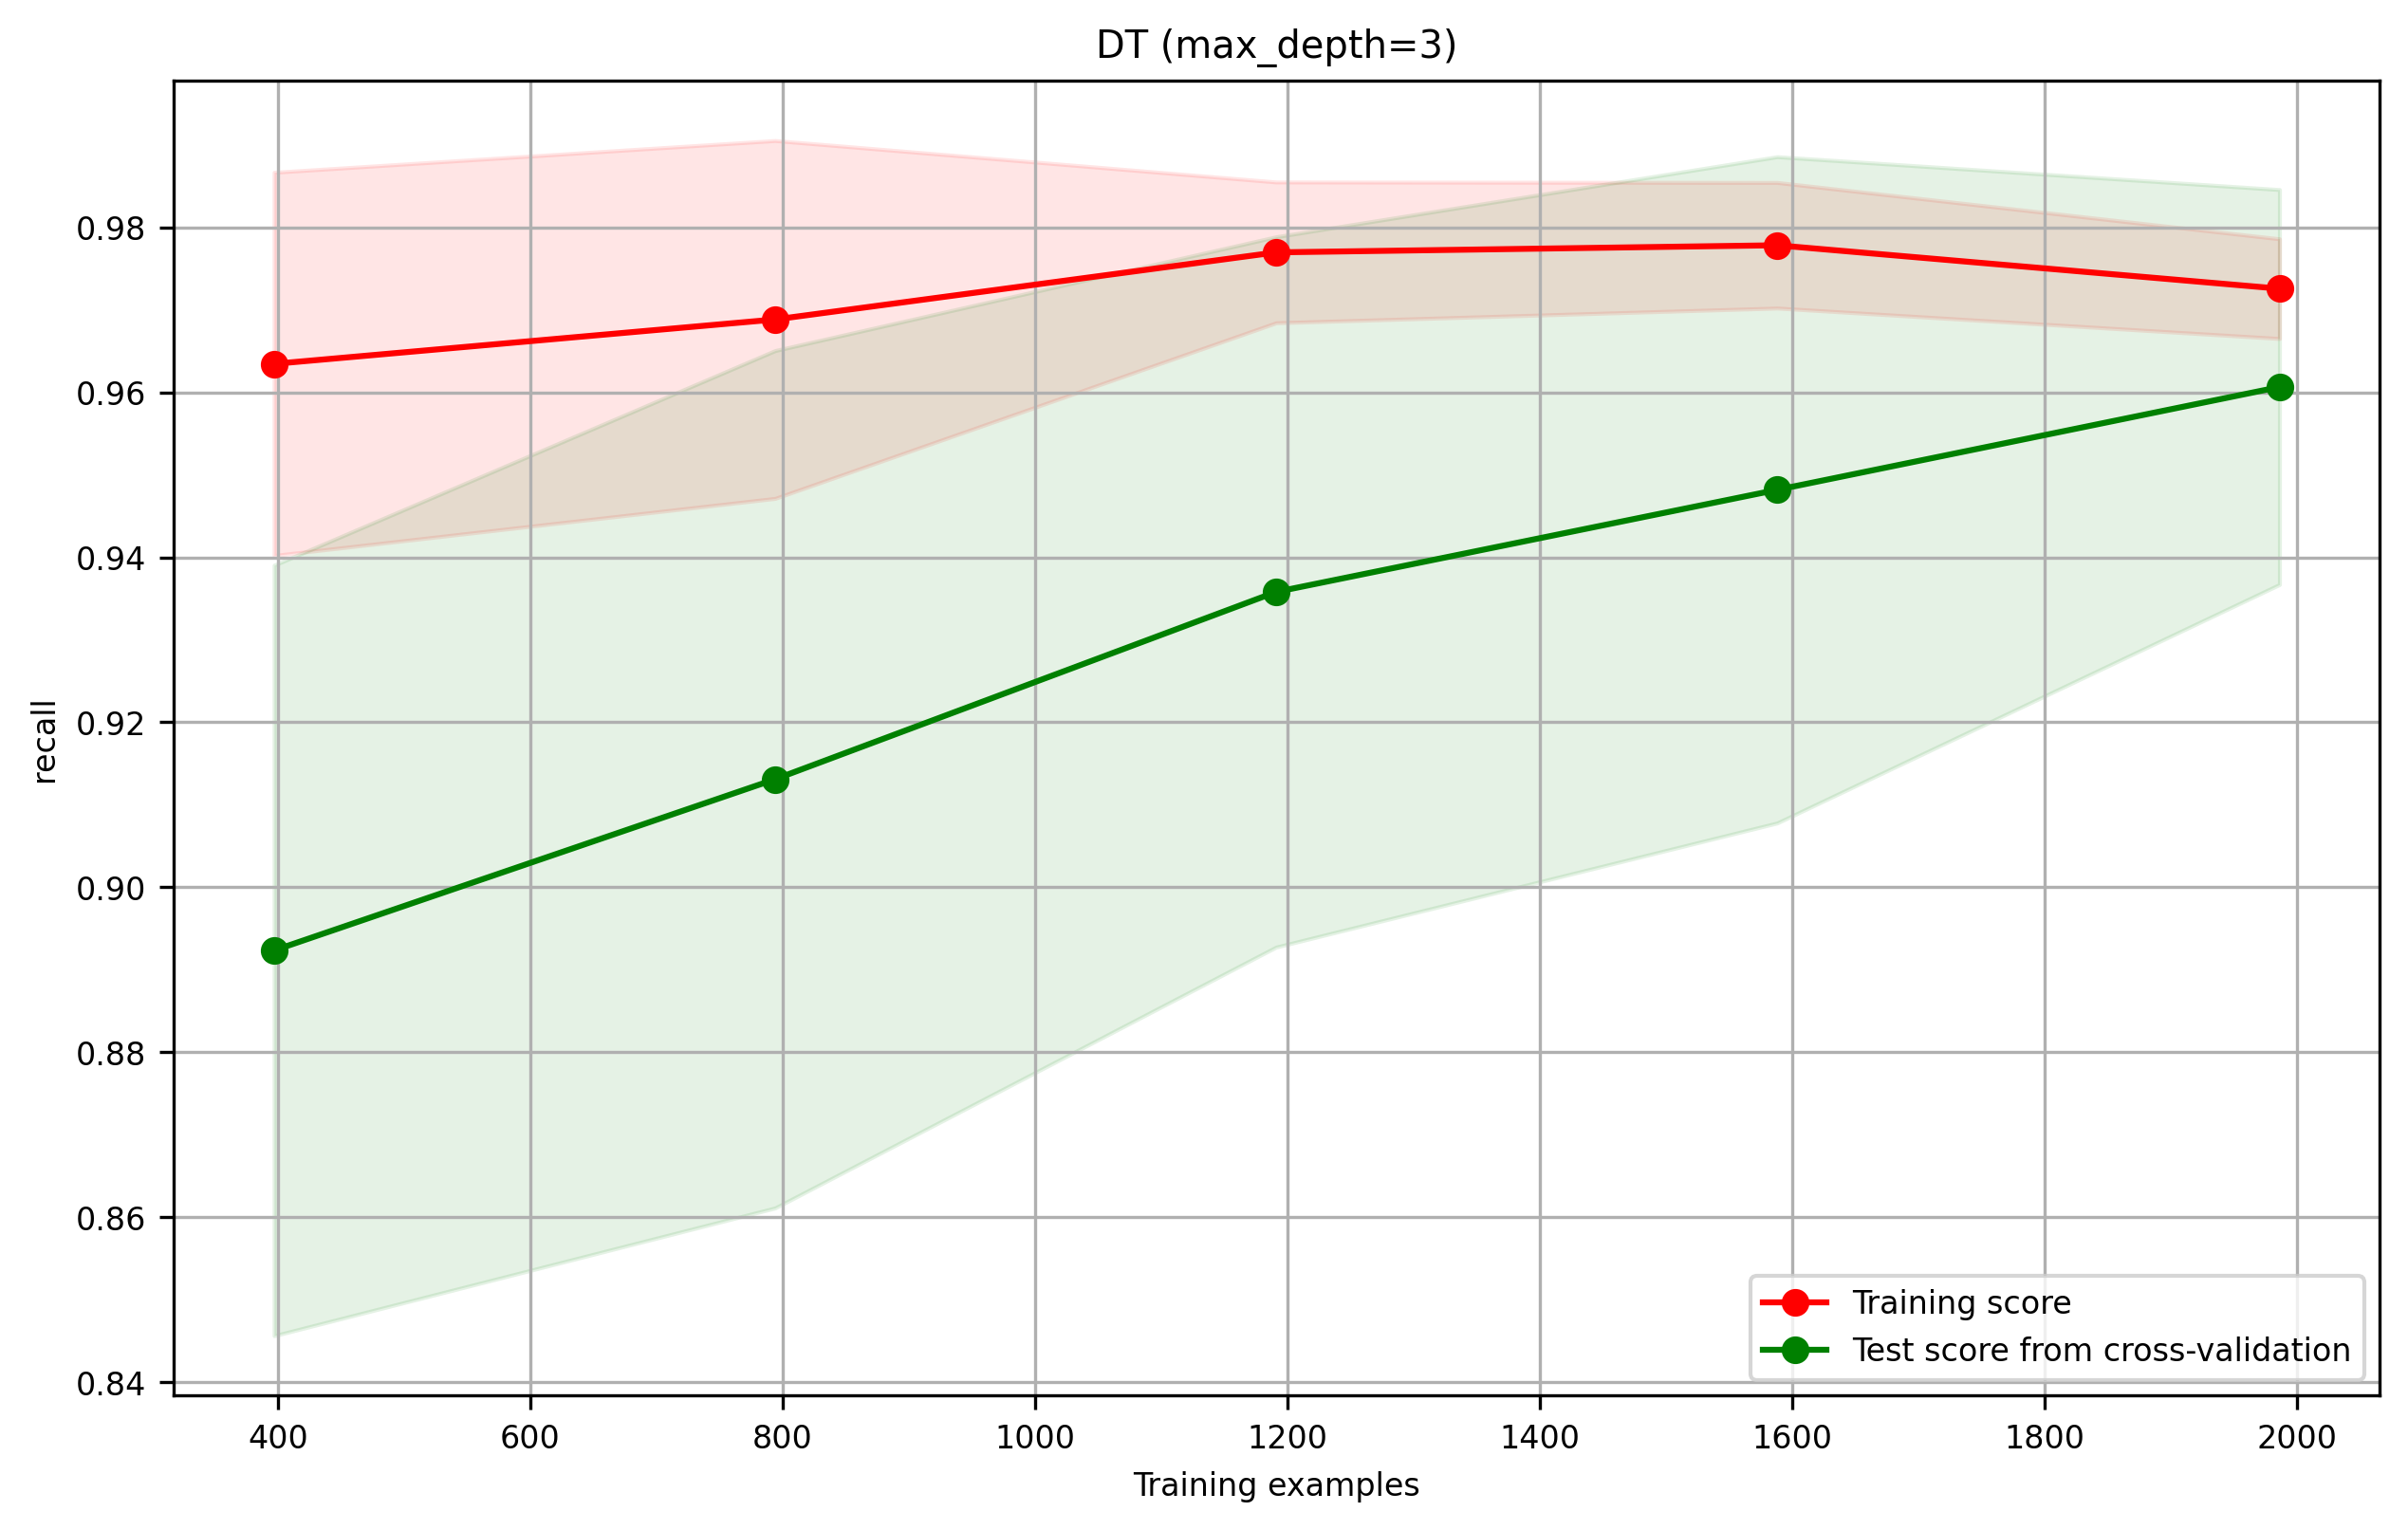

In [47]:
plot_learning_curve(model_tree_simple, 'DT (max_depth=3)', X, y, cv=cv3, scoring='recall')

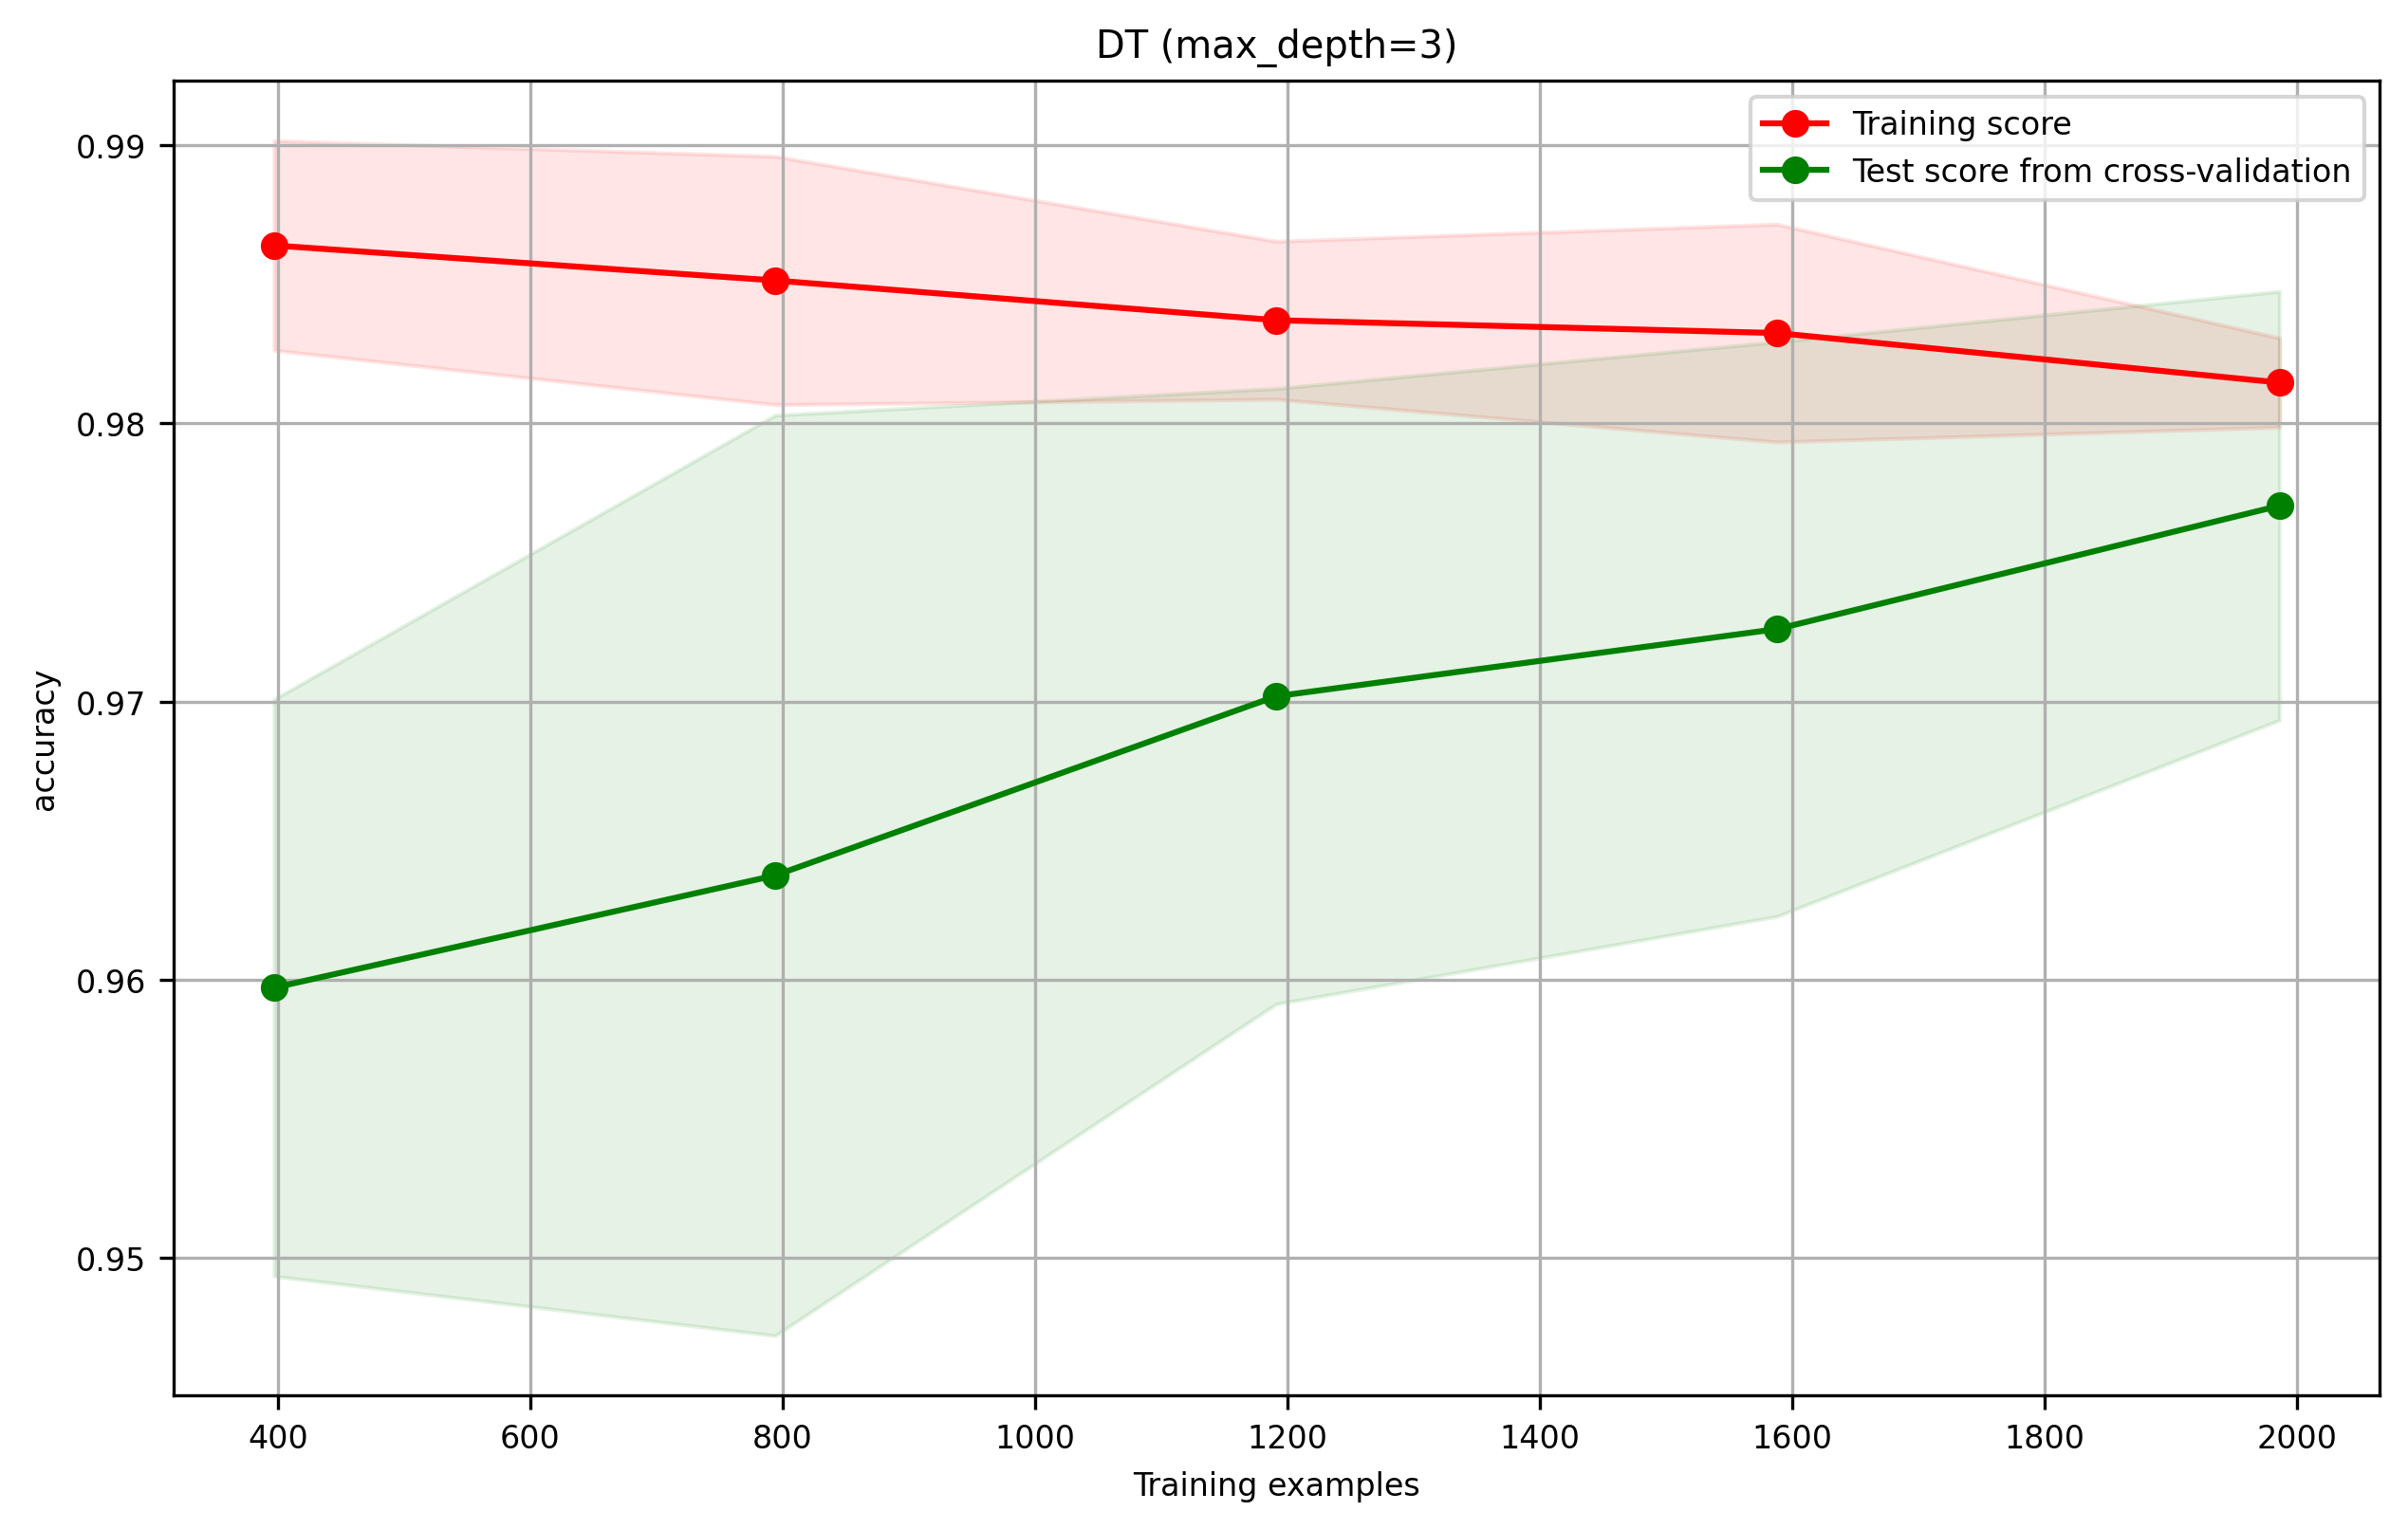

In [48]:
plot_learning_curve(model_tree_simple, 'DT (max_depth=3)', X, y, cv=cv3, scoring='accuracy');

### Preguntas

A partir de los resultados obtenidos con validación cruzada:

1. ¿Qué ocurrió con el rendimiento al restringir la complejidad del árbol?

El rendimiento mejoró en las cuatro métricas. El árbol simple de una profundad máxima 3, obtuvo accuracy 0.977 a diferencia de 0.971 que obtuvo el árbol base, precision 0.925 contra 0.920, recall 0.961 contra 0.932 y F1 0.942 contra 0.926. La mejora más notable se dio en recall subiendo app 0.03.

2. ¿El árbol más simple empeoró o mejoró la generalización?

Mejoró. Un árbol restringido, con menos capacidad de memorizar el set de entrenamiento, generaliza mejor a datos no vistos, esto puede ser observado en scores de validación cruzada más altos en todas las métricas.

3. ¿Qué sugieren estos resultados sobre el árbol base?

Confirman que el árbol base estaba sobreajustando. Como su score de entrenamiento era perfecto, era claro que estaba no estaba generalizando, sino que memorizaba ruido específico del set de entrenamiento. Restarle complejidad mejoró el desempeño en validación, lo que evidencia que el árbol base tenía varianza alta.

4. En este problema, ¿parece conveniente usar el árbol sin restricciones?

No. El árbol simple supera al árbol base en las cuatro métricas evaluadas, por lo que no vale la pena la mayor complejidad e interpretabilidad reducida del árbol sin restricciones cuando un modelo más simple funciona mejor.

5. ¿Qué métrica le parece más importante para decidir entre ambos modelos?

Si buscamos encontrar la mayor cantidad posible de RR Lyrae (maximizar completitud), el recall es la métrica clave, y ahí la diferencia a favor del árbol simple es la más grande al tener 0.961 contra 0.932. Si el objetivo fuera una muestra final pura, la precision importaría más, aunque la diferencia ahí es menor. Como métrica de balance general, el F1 score también favorece claramente al árbol simple, teniendo 0.942 contra 0.926.

## Desafío: comparar con kNN

Hasta ahora trabajamos con árboles de decisión. Ahora comparemos ese enfoque con un clasificador distinto: **k-Nearest Neighbors (kNN)**.

Entrene un modelo kNN y compárelo con el árbol simple usando validación cruzada estratificada. Recuerde que kNN está basado en distancias, por lo que antes de entrenarlo debe escalar las variables.

### Instrucciones

1. Entrene un modelo kNN con `k=5`.
2. Use un `StandardScaler` antes del clasificador.
3. Evalúe el modelo con validación cruzada estratificada usando:
   - accuracy
   - precision
   - recall
   - F1-score
4. Compare sus resultados con los del árbol simple.
5. Luego explore distintos valores de `k` y vea cómo cambian las métricas.

### Preguntas

1. ¿Cómo se compara el rendimiento de kNN con el del árbol simple?

Notamos kNN con k = 5 tiene un rendimiento muy parecido al árbol simple, incluso levemente superior en algunas métricas. kNN muestra desviaciones estándar más bajas en casi todas las métricas, lo que sugiere que es un modelo ligeramente más estable entre folds. En general, ambos modelos tienen un desempeño comparable, con una leve ventaja para kNN en recall y F1.

2. ¿Qué ocurre cuando `k` es muy pequeño?

Cuando se trabaja con k pequeño por ejemplo k = 1, el rendimiento es más bajo, ya que al escoger un solo vecino el modelo es sensible outliers. Por lo que el modelo realiza un sobre ajuste y no generaliza de manera adecuada.

3. ¿Qué ocurre cuando `k` es muy grande?

A medida que k crece por ejemplo con k=15 ,25 , 51 el accuracy y la precision bajan suavemente, el recall sigue siendo alto. Se produce debido ya que si promediamos con muchos vecinos el modelo empieza a priorizar los datos mayoritarios refiriendose a los que no son RR Lyrae en las predicciones, por lo que generaria false positives aunque de todas maneras sigue detectando la gran parte de los true positive. 

4. ¿Qué valor de `k` parece dar el mejor equilibrio entre precision y recall?

Para poder determinar un valor k que pueda ser el mejor equilibrio entre precision y recall se debe de trabajar don el F1 score. Con k = 7 el f1 score es el más alto con un valor de 0.946. Los valores de presicion y recall son de 0.918 y 0.975 respectivamente, por lo que se podría considerar como el mejor equilibrio

5. ¿Qué ventaja podría tener kNN si la frontera entre clases no es rectangular?

Un árbol de decision construye su frontera mediante cortes perpendiculares a los ejes, es decir, divide segun si la variable es mayor o menor que un valor. kNN no impone ninguna forma geométrica, la frontera se adapta a la distribución de los datos,    

Un DT construye su frontera mediante cortes a los ejes, es decir, divide segun si la variable es mayor o menor que un valor. kNN no impone ninguna forma geométrica, la frontera se adapta a la distribución de los datos, puede tomar forma como curvas, diagonales u otra forma.

In [49]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [ ]:
knn_model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))
scores_knn = cross_validate(
    knn_model,
    X, y, cv=cv3, scoring=scoring
)

print("kNN (k=5) ")
for m in scoring:
    print(f"{m:10s}: {scores_knn['test_' + m].mean():.3f} ± {scores_knn['test_' + m].std():.3f}")

print("\nÁrbol Simple (max_depth=3) ")
for m in scoring:
    print(f"{m:10s}: {scores_simple['test_' + m].mean():.3f} ± {scores_simple['test_' + m].std():.3f}")

kNN (k=5) 
accuracy  : 0.978 ± 0.006
precision : 0.922 ± 0.021
recall    : 0.969 ± 0.011
f1        : 0.945 ± 0.015

Árbol Simple (max_depth=3) 
accuracy  : 0.977 ± 0.008
precision : 0.925 ± 0.023
recall    : 0.961 ± 0.024
f1        : 0.942 ± 0.019


In [51]:
valores_k = [1, 3, 5, 7, 9, 15, 25, 51]

resultados_k = {}

for k in valores_k:
    modelo_k = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    scores_k = cross_validate(modelo_k, X, y, cv=cv3, scoring=scoring)
    resultados_k[k] = {m: scores_k['test_' + m].mean() for m in scoring}

    print(f"k={k:3d} : " + " : ".join(f"{m}: {resultados_k[k][m]:.3f}" for m in scoring))

k=  1 : accuracy: 0.968 : precision: 0.914 : recall: 0.923 : f1: 0.919
k=  3 : accuracy: 0.977 : precision: 0.923 : recall: 0.961 : f1: 0.941
k=  5 : accuracy: 0.978 : precision: 0.922 : recall: 0.969 : f1: 0.945
k=  7 : accuracy: 0.978 : precision: 0.918 : recall: 0.975 : f1: 0.946
k=  9 : accuracy: 0.977 : precision: 0.912 : recall: 0.977 : f1: 0.943
k= 15 : accuracy: 0.974 : precision: 0.900 : recall: 0.975 : f1: 0.936
k= 25 : accuracy: 0.971 : precision: 0.893 : recall: 0.971 : f1: 0.930
k= 51 : accuracy: 0.971 : precision: 0.889 : recall: 0.973 : f1: 0.929


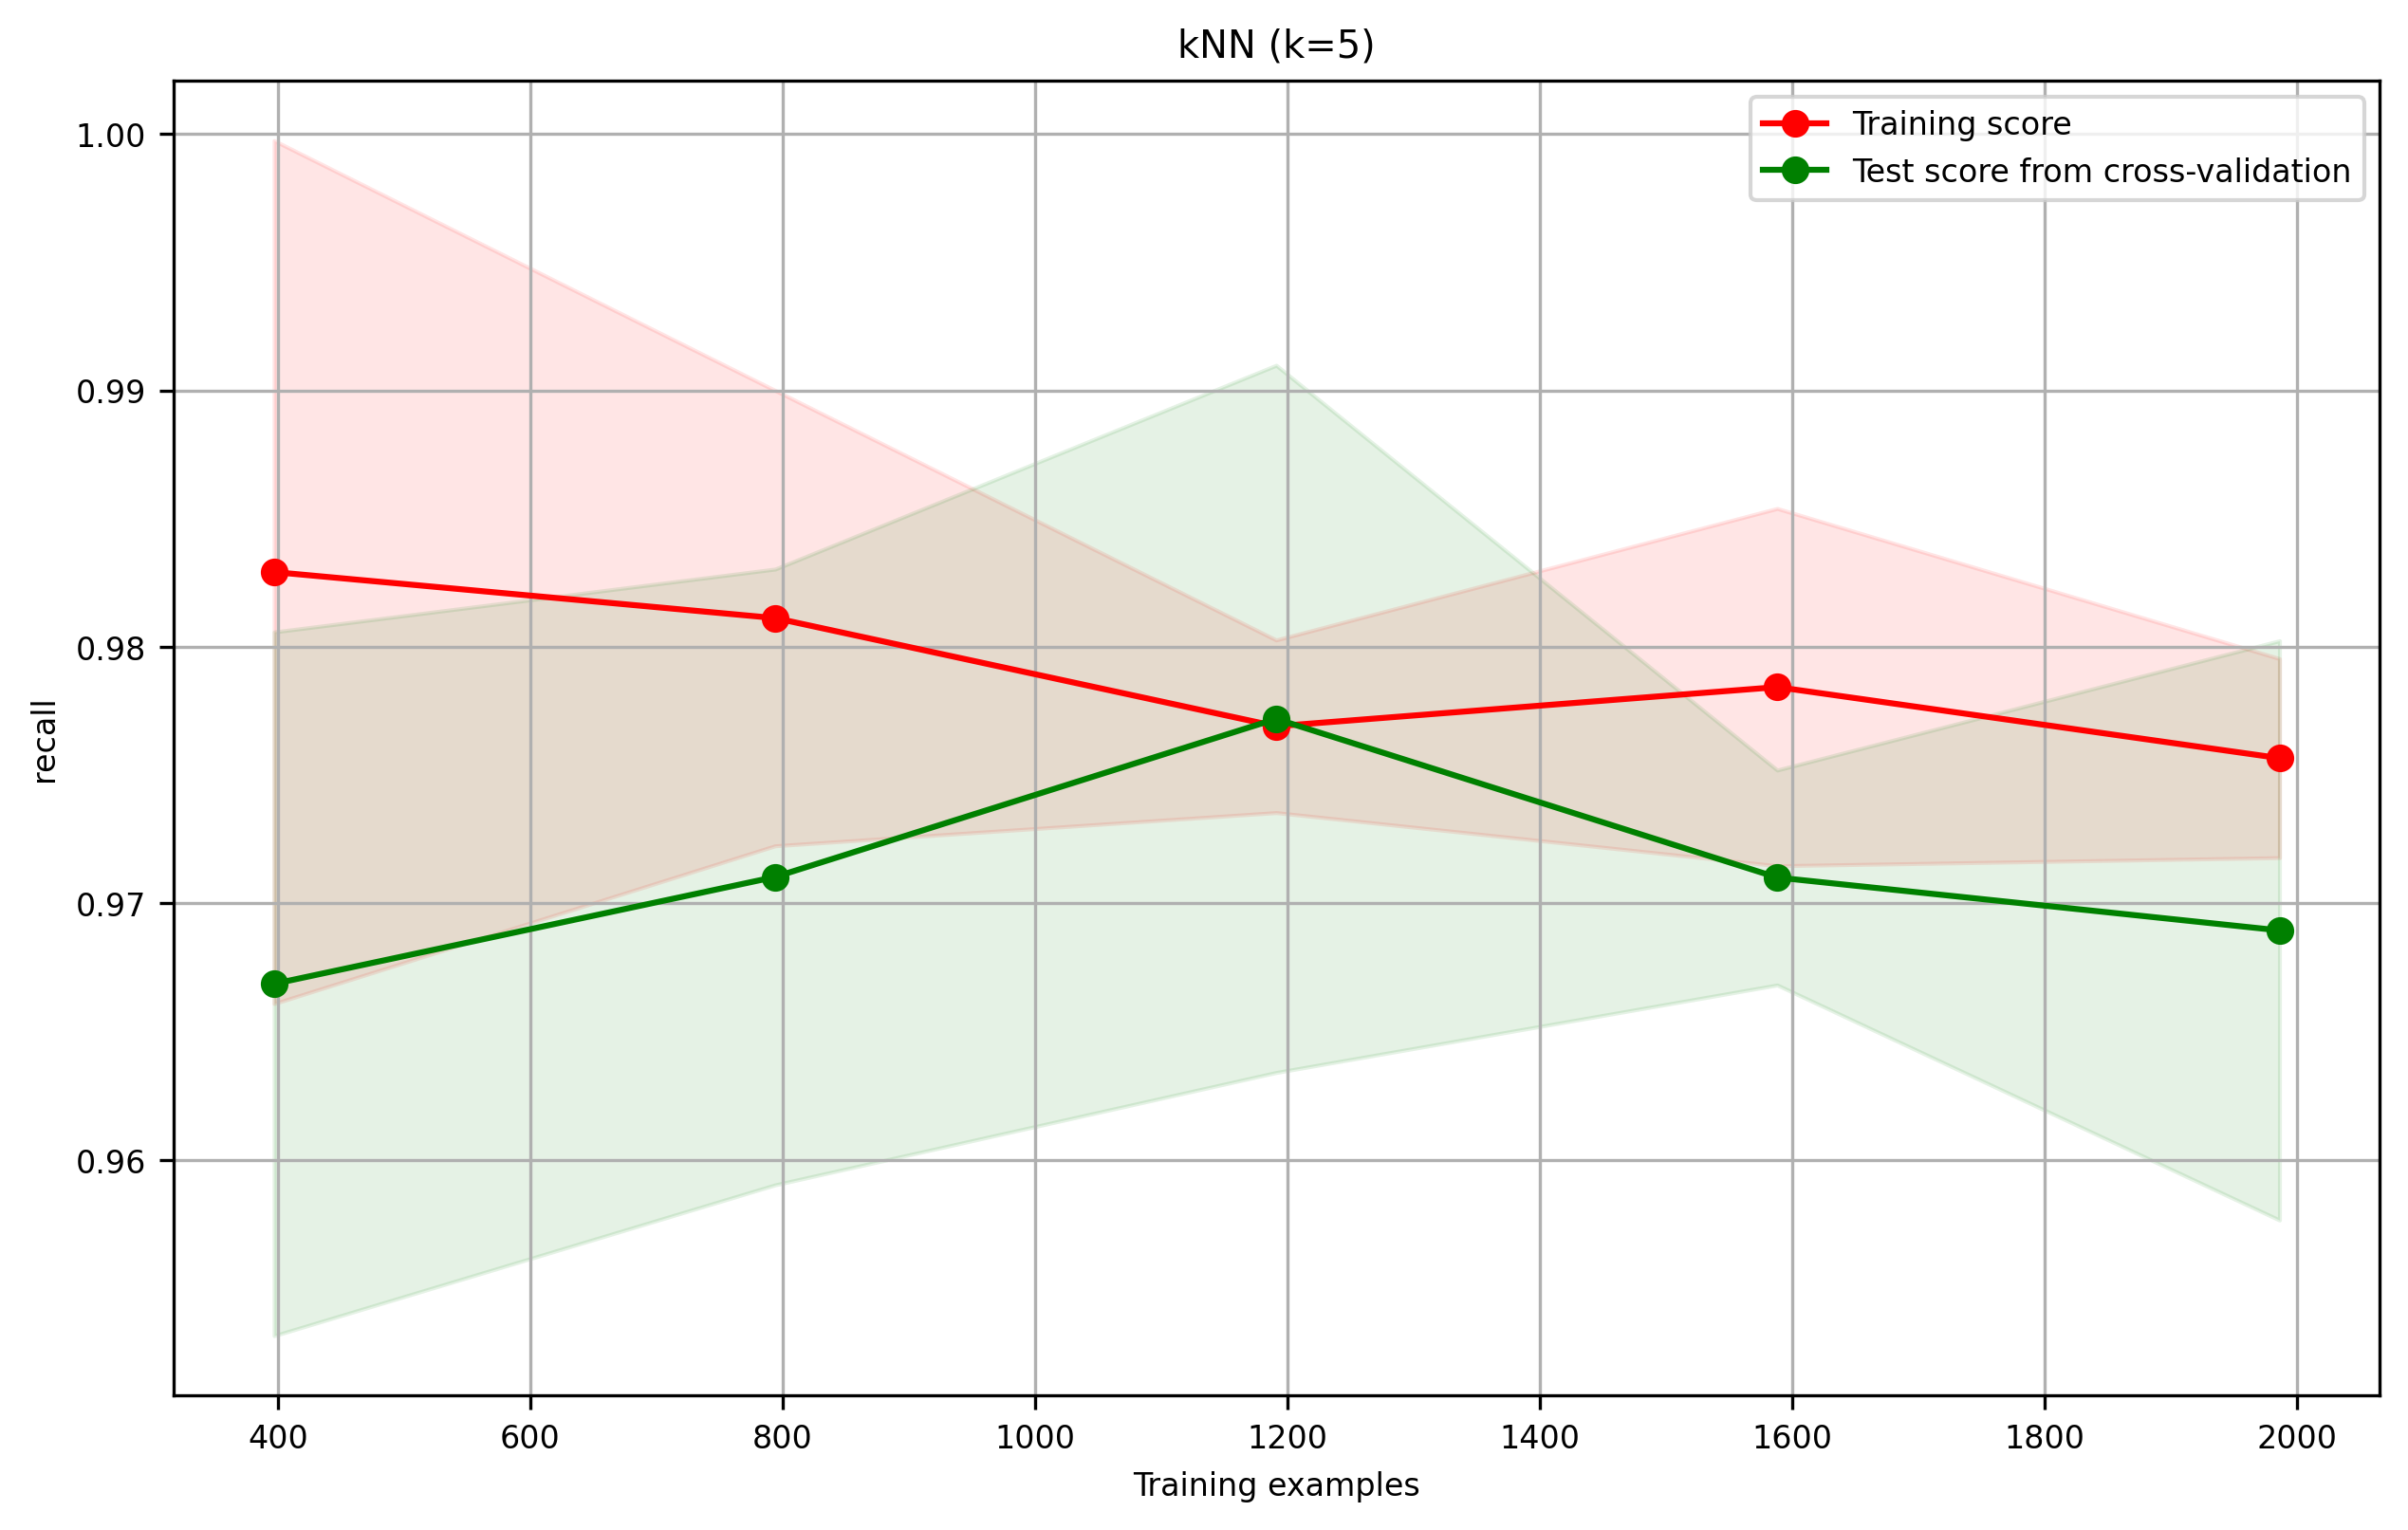

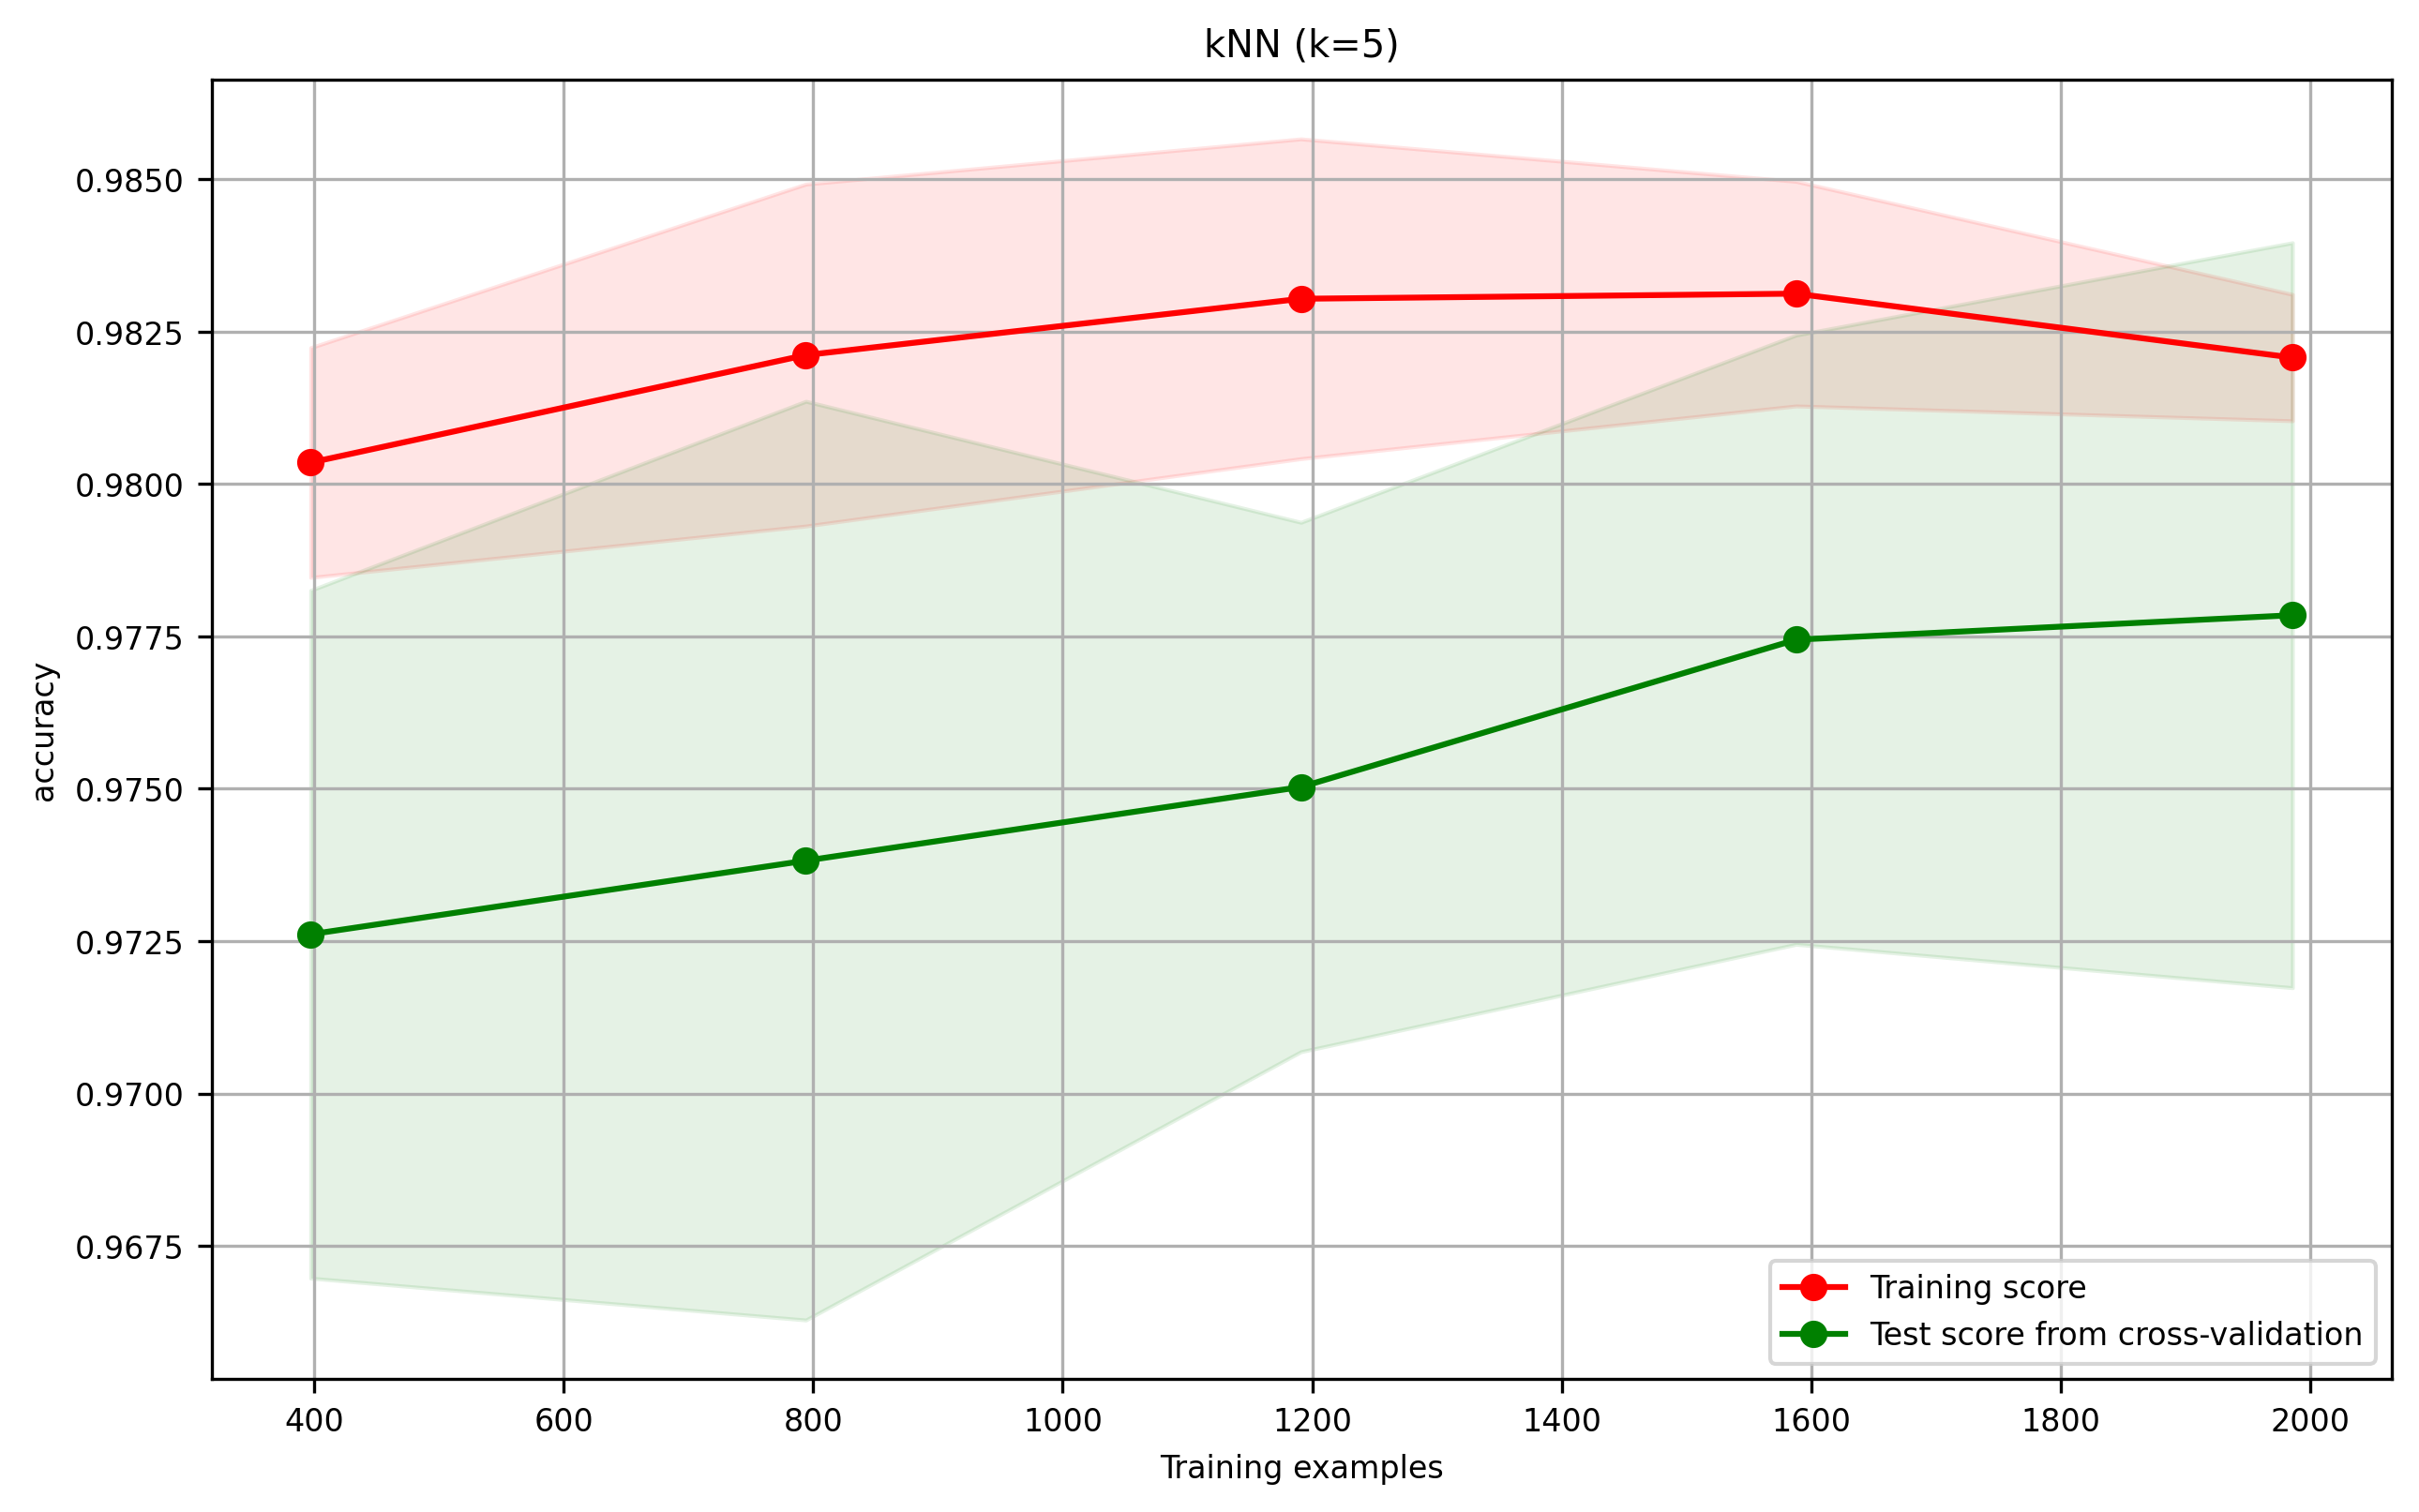

Exception ignored in: <function ResourceTracker.__del__ at 0x775e60b99f80>
Traceback (most recent call last):
  File "/home/ivanf/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/ivanf/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/ivanf/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7c3c0719df80>
Traceback (most recent call last):
  File "/home/ivanf/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/ivanf/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/ivanf/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ 

In [52]:
plot_learning_curve(knn_model, 'kNN (k=5)', X, y, cv=cv3, scoring='recall');
plot_learning_curve(knn_model, 'kNN (k=5)', X, y, cv=cv3, scoring='accuracy');

## Cierre

En esta actividad vimos que evaluar un clasificador no consiste solo en obtener un score alto, sino en interpretar qué está midiendo cada métrica y cómo se construyen los conjuntos de validación. En este problema, el uso de validación cruzada estratificada fue importante para obtener una evaluación más estable y representativa.

También observamos que un modelo más complejo no siempre generaliza mejor. Aunque el árbol base ajustaba perfectamente los datos de entrenamiento, un árbol más simple logró mejores resultados en validación cruzada, lo que sugiere que reducir la complejidad ayudó a disminuir el sobreajuste.